In [1]:
# 🔧 DIAGNÓSTICO DE ERRO CUDA - Execute antes de treinar
import torch
import torch.cuda as cuda

print("="*80)
print("📊 DIAGNÓSTICO DO SISTEMA GPU")
print("="*80)

# Verificar GPU
print(f"CUDA disponível: {torch.cuda.is_available()}")
print(f"GPU encontrada: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Nenhuma'}")

if torch.cuda.is_available():
    # Limpar cache antes de começar
    print("\n🧹 Limpando cache de GPU...")
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    # Informações de memória
    props = torch.cuda.get_device_properties(0)
    total_memory = props.total_memory / 1e9
    print(f"Memória total da GPU: {total_memory:.2f} GB")

    allocated = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    print(f"Memória alocada: {allocated:.2f} GB")
    print(f"Memória reservada: {reserved:.2f} GB")
    print(f"Memória livre: {(total_memory - reserved):.2f} GB")

    # Verificar compatibilidade
    print(f"\nVersão CUDA: {torch.version.cuda}")
    print(f"Versão cuDNN: {torch.backends.cudnn.version()}")
    print(f"cuDNN habilitado: {torch.backends.cudnn.enabled}")

else:
    print("⚠️  CUDA não disponível! Usando CPU (muito lento).")

print("="*80 + "\n")

📊 DIAGNÓSTICO DO SISTEMA GPU
CUDA disponível: True
GPU encontrada: Tesla T4

🧹 Limpando cache de GPU...
Memória total da GPU: 15.64 GB
Memória alocada: 0.00 GB
Memória reservada: 0.00 GB
Memória livre: 15.64 GB

Versão CUDA: 12.8
Versão cuDNN: 91900
cuDNN habilitado: True



In [2]:
import pandas as pd
from PIL import Image, ImageChops
import numpy as np
import torch
from sklearn.model_selection import KFold
from torch.utils.data import  DataLoader, TensorDataset, Dataset
from torch import nn
import timm
from tqdm.notebook import tqdm
import torch.optim as optim
import os

In [ ]:
print()

## Load and copy dataset to content on Drive or Local

In [3]:

import time
ts = int(time.time())
timestamp = str(ts)

if os.getenv("IS_LOCAL"):
    FILE_PATH = 'dataset_FA_OUTROS_NORMAL_BINARY_HOT_ENCODING.csv'

    print("Iniciando o programa em execucao Local")
    print("Parametros de Execucao Local:")
    folds = 5
    epochs = 50
    BATCH_SIZE = 8 # ✅ REDUZIDO de 64 para 32 (evita erro CUDA)
    N_samples = None  # Use None para usar todos os dados
    flg_salvar_modelos = True
    path = '/home/leo/Documents/ecg_classifier/dataset/database_ptbxl/'
    path_out = 'saida_123/saidas/'
    OUTPUT_TEST_PATH = 'OUTPUTTESTES/'
    OUTPUT_MODEL_PATH = 'OUTPUTMODELS/'

    print(f"  Numero de folds para K-Fold Cross Validation: {folds}")

    print(f"  Tamanho do batch para treinamento: {BATCH_SIZE}")

    print(f"  Numero de epocas para treinamento: {epochs}")
else:
    from google.colab import drive
    drive.mount('/content/drive')
    folds = 5
    epochs = 50
    BATCH_SIZE = 64 # ✅ REDUZIDO de 64 para 32 (evita erro CUDA)
    N_samples = None  # Use None para usar todos os dados
    flg_salvar_modelos = True
    os.system('cp  "/content/drive/MyDrive/dataset_AFIB_Others/database_ptbxl.zip" "/content/dataset.zip"')
    os.system('unzip -oq dataset.zip')
    FILE_PATH = '/content/drive/MyDrive/dataset_AFIB_Others/dataset_FA_OUTROS_NORMAL_BINARY_HOT_ENCODING.csv'
    path = '/content/content/drive/MyDrive/dataset_AFIB_Others/database_ptbxl/'
    path_out = f'/content/drive/MyDrive/dataset_AFIB_Others/saida_{timestamp}/saidas/'
    OUTPUT_TEST_PATH = f'/content/drive/MyDrive/dataset_AFIB_Others/OUTPUTTESTES/'
    OUTPUT_MODEL_PATH = f'/content/drive/MyDrive/dataset_AFIB_Others/OUTPUTMODELS/'


Mounted at /content/drive


In [4]:
data = pd.read_csv(FILE_PATH)
tensor_label = data[['NORMAL','Other','AFIB']][0:N_samples]
tensor_label.value_counts()
data['NORMAL'].isna().sum()

np.int64(0)

## Load dataset Local

## Filtro de Imagem

In [5]:
from PIL import Image, ImageChops
import numpy as np
import os
import shutil
import io
from pathlib import Path
def treat_image_PIL(img_path, type_return=2):
    ''''
    Input: Img_path, type return.

    Img_path: path da imagem em formato png, img...
    type_return: 1-> retorno como PIL.
                2 ou sem type_return -> retorno como numpy array tipo uint8

    Output:
    '''
    im = Image.open(path+img_path)

    # Size of the image in pixels (size of original image)
    # (This is not mandatory)
    width, height = im.size

    rgb =Image.Image.split(im)

    data =rgb
    b= data[0]
    g= data[1]
    r= data[2]
    #img_out = b+g+.5*r
    #img_out_2 = img_out[500:1600, 50:2100]

    newsize = (256, 256)
   # im3 =ImageChops.subtract(mask,b, scale=1.0, offset=0)

    b1 = b.crop((120,500,2100,1600))
    g1 = g.crop((120,500,2100,1600))
    r1 = r.crop((120,500,2100,1600))
    im1 = b1.resize(newsize, Image.Resampling.LANCZOS).convert('L')
    im2 = g1.resize(newsize, Image.Resampling.LANCZOS).convert('L')
    im3 = r1.resize(newsize, Image.Resampling.LANCZOS).convert('L')
    if type_return ==1:
        return Image.merge("RGB",(im1,im1,im1))
    elif type_return ==2:

        return np.array([im1,im1,im1],dtype=np.uint8)
    elif type_return ==3:

        return np.array([im1,im2,im3],dtype=np.uint8)
    elif type_return ==4:

        return np.array(im3,dtype=np.uint8)

def save_file_to_dir(file_obj, directory, filename):
    """
    Save a file to `directory` with the given `filename`.

    Parameters
    - file_obj: a PIL Image, a filesystem path (str or Path) to an existing file,
                bytes/bytearray, or a file-like object with a .read() method.
    - directory: target directory where the file will be saved.
    - filename: the name to use for the saved file (including extension if desired).

    Returns
    - full path (str) to the saved file.

    Raises
    - FileNotFoundError if a provided source path does not exist.
    - ValueError if the provided file_obj type is unsupported.
    """
    os.makedirs(directory, exist_ok=True)
    dest = os.path.join(directory, filename)

    # PIL Image
    if isinstance(file_obj, Image.Image):
        file_obj.save(dest)
        return dest

    # Path-like or string pointing to an existing file
    if isinstance(file_obj, (str, Path)):
        src = str(file_obj)
        if os.path.exists(src):
            shutil.copy(src, dest)
            return dest
        raise FileNotFoundError(f"Source path not found: {src}")

    # File-like object
    if hasattr(file_obj, "read"):
        data = file_obj.read()
        # If read() returned bytes -> try open as image, otherwise write raw
        if isinstance(data, (bytes, bytearray)):
            try:
                img = Image.open(io.BytesIO(data))
                img.save(dest)
                return dest
            except Exception:
                with open(dest, "wb") as f:
                    f.write(data)
                return dest
        else:
            # assume text
            with open(dest, "w", encoding="utf-8") as f:
                f.write(data)
            return dest

    # Raw bytes
    if isinstance(file_obj, (bytes, bytearray)):
        try:
            img = Image.open(io.BytesIO(file_obj))
            img.save(dest)
            return dest
        except Exception:
            with open(dest, "wb") as f:
                f.write(file_obj)
            return dest

    raise ValueError("file_obj must be a PIL.Image, path string/Path, bytes or file-like object")

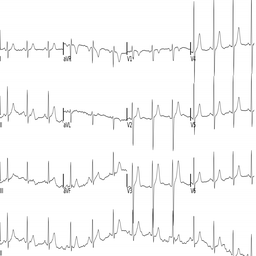

(3, 256, 256)
uint8


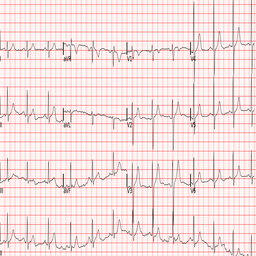

In [6]:
## Exemplo de uso de resize de imagem
image  = treat_image_PIL('00004_lr-0.png',1)
display(image)

## treat image pil as array and return to Image PIL and display
img_array = treat_image_PIL('00004_lr-0.png',3)
print(img_array.shape)
print(img_array.dtype)
img_pil = Image.fromarray(img_array.transpose(1, 2, 0))  # (3, 256, 256) → (256, 256, 3)
display(img_pil)

In [7]:
import os
## Cria funcao para validar se pasta a ser inserida existe. Caso nao exista, cria a pasta
def create_folder_if_not_exists(folder_path):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f'Pasta {folder_path} criada.')
    else:
        print(f'Pasta {folder_path} ja existe.')


In [8]:
from torch.utils.data import  Dataset

class Subset(Dataset):
    r"""
    Subset of a dataset at specified indices.

    Arguments:
        dataset (Dataset): The whole Dataset
        indices (sequence): Indices in the whole set selected for subset
    """
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = indices

    def __getitem__(self, idx):
        return self.dataset[self.indices[idx]]

    def __len__(self):
        return len(self.indices)

    @property
    def classes(self):
        return self.data.classes

    def shape(self):
        return self.dataset

## Loop de Treinamento e Validacao

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device: " + str(device))

Device: cuda:0


In [10]:
import torch
from torch import nn
import numpy as np
import os
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device: " + str(device))

def salvar_model(model, path = '/content/drive/MyDrive/4000-files/output/modelos', name_file='model.pth'):
    create_folder_if_not_exists(path)

    full_path = os.path.join(path, name_file)
    torch.save(model.state_dict(), full_path)

def salvar_metricas(path, name_file_train='train_loss_total.npy', name_file_val='val_loss_total.npy',predict_label=None, true_label=None):
    create_folder_if_not_exists(path)
    full_path_train = os.path.join(path, name_file_train)
    full_path_val = os.path.join(path, name_file_val)
    np.save(full_path_train, np.array(predict_label))
    np.save(full_path_val, np.array(true_label))
    print(f'Metricas salvas em {path} com os nomes {name_file_train} e {name_file_val} e tamanhos {np.array(predict_label).shape} e {np.array(true_label).shape}')

def simple_loop(model, train_image, val_image, epochs, batch_size, fold_index, patience=10, delta=0.0001, device_input=None, l2_lambda=1e-4, class_weights=None):
    """
    Loop de treinamento e validação com Early Stopping, regularização L2 explícita e monitoramento de métricas.
    """
    if device_input is None:
        device_input = device

    num_epochs = epochs
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_f1s, val_f1s = [], []
    iter_size = batch_size
    print(f'Number of training images per iteration: {iter_size}')
    print(f'Device sendo usado: {device_input}')
    print(f'Penalidade L2 aplicada: {l2_lambda}')

    try:
        model = model.to(device_input)
        print(f'✓ Modelo movido para {device_input}')
    except Exception as e:
        print(f'❌ ERRO ao mover modelo para device: {e}')
        raise

    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(device_input) if class_weights is not None else None,
        label_smoothing=0.05
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        threshold=1e-4,
        cooldown=1,
        min_lr=1e-7
    )
    predict_label_full_train = []
    predict_label_full = []
    true_label_full_train = []
    true_label_full = []

    for epoch in range(num_epochs):
        model.train()
        predict_label_train = []
        true_label_train = []
        running_loss_train = 0.0

        try:
            for images, labels in tqdm(train_image, desc='Training loop'):
                images = images.to(device_input)
                labels = labels.to(device_input)
                images = images.to(torch.float32)
                labels = labels.to(torch.float32)
                optimizer.zero_grad()

                outputs = model(images)

                pred_train = torch.argmax(outputs, dim=1)
                _true = torch.argmax(labels, dim=1)

                loss_train = criterion(outputs, labels)
                loss_train.backward()

                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                _pred_train = torch.argmax(outputs, dim=1)
                running_loss_train += loss_train.item() * labels.size(0)

                try:
                    pred_list = _pred_train.cpu().numpy().astype(int).tolist()
                    true_list = _true.cpu().numpy().astype(int).tolist()

                    if not isinstance(pred_list, list):
                        pred_list = [pred_list]
                    if not isinstance(true_list, list):
                        true_list = [true_list]

                    if len(pred_list) == iter_size:
                        predict_label_train.append(pred_list)
                        true_label_train.append(true_list)

                except Exception as e:
                    print(f"⚠ Erro ao salvar predições de treinamento: {e}")

        except RuntimeError as e:
            if "CUDA" in str(e) or "assert" in str(e).lower():
                print(f"\n❌ ERRO CUDA durante treinamento: {e}")
                print("💡 Sugestões:")
                print("   1. Reduza BATCH_SIZE")
                print("   2. Execute torch.cuda.empty_cache()")
                print("   3. Use modelos menores")
                torch.cuda.empty_cache()
                raise
            else:
                raise

        train_loss = running_loss_train / len(train_image.dataset)
        train_losses.append(train_loss)

        try:
            if predict_label_train and true_label_train:
                train_preds = np.concatenate(predict_label_train)
                train_trues = np.concatenate(true_label_train)
                train_acc = accuracy_score(train_trues, train_preds)
                train_f1 = f1_score(train_trues, train_preds, average='weighted', zero_division=0)
                train_accuracies.append(train_acc)
                train_f1s.append(train_f1)
        except Exception as e:
            print(f"⚠ Erro ao calcular métricas de treinamento: {e}")
            print(f"  predict_label_train: {train_preds}")
            print(f"  true_label_train: {train_trues}")
        try:
            _p_train = predict_label_train
            _t_train = true_label_train
            predict_label_full_train.append(_p_train)
            true_label_full_train.append(_t_train)
        except Exception as e:
            print(f"⚠ Erro ao concatenar métricas de treinamento: {e}")
            print(f"  predict_label_train: {train_preds}")
            print(f"  true_label_train: {train_trues}")

        model.eval()
        running_loss_valid = 0.0
        predict_label = []
        true_label = []
        _iter = 0

        try:
            with torch.no_grad():
                for images, labels in tqdm(val_image, desc='Validation loop'):
                    images = images.to(device_input)
                    labels = labels.to(device_input)
                    images = images.to(torch.float32)
                    labels = labels.to(torch.float32)

                    outputs = model(images)
                    pred_out = torch.argmax(outputs, dim=1)
                    true_out = torch.argmax(labels, dim=1)

                    loss_valid = criterion(outputs, labels)

                    try:
                        pred_list = pred_out.cpu().numpy().astype(int).tolist()
                        true_list = true_out.cpu().numpy().astype(int).tolist()

                        if not isinstance(pred_list, list):
                            pred_list = [pred_list]
                        if not isinstance(true_list, list):
                            true_list = [true_list]

                        if len(pred_list) == iter_size:
                            predict_label.append(pred_list)
                            true_label.append(true_list)

                    except Exception as e:
                        print(f"⚠ Erro ao salvar predições de validação: {e}")

                    running_loss_valid += loss_valid.item() * labels.size(0)
                    _iter += 1

        except RuntimeError as e:
            if "CUDA" in str(e) or "assert" in str(e).lower():
                print(f"\n❌ ERRO CUDA durante validação: {e}")
                torch.cuda.empty_cache()
                raise
            else:
                raise

        val_loss = running_loss_valid / len(val_image.dataset)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        val_precision = 0
        val_recall = 0
        try:
            if predict_label and true_label:
                val_preds = np.concatenate(predict_label)
                val_trues = np.concatenate(true_label)
                val_acc = accuracy_score(val_trues, val_preds)
                val_f1 = f1_score(val_trues, val_preds, average='weighted', zero_division=0)
                val_precision = precision_score(val_trues, val_preds, average='weighted', zero_division=0)
                val_recall = recall_score(val_trues, val_preds, average='weighted', zero_division=0)
                val_accuracies.append(val_acc)
                val_f1s.append(val_f1)
        except Exception as e:
            print(f"⚠ Erro ao calcular métricas de validação: {e}")

        try:
            _p = predict_label
            _t = true_label
            predict_label_full.append(_p)
            true_label_full.append(_t)
        except Exception as e:
            print(f"⚠ Erro ao concatenar métricas de validação: {e}")

        print(f"\n{'='*80}")
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*80}")
        print(f"Train Loss: {train_loss:.6f}", end="")
        if train_accuracies:
            print(f" | Train Acc: {train_accuracies[-1]:.4f}", end="")
            print(f" | Train F1: {train_f1s[-1]:.4f}", end="")

        print()
        print(f"Val Loss:   {val_loss:.6f}", end="")
        if val_accuracies:
            print(f" | Val Acc: {val_accuracies[-1]:.4f}", end="")
            print(f" | Val F1: {val_f1s[-1]:.4f}", end="")
            print(f" | Precision: {val_precision:.4f}", end="")
            print(f" | Recall: {val_recall:.4f}", end="")
        print()
        print(f"{'='*80}\n")

    predict_label_full_out = np.array(predict_label_full, dtype=object)
    true_label_full_out = np.array(true_label_full, dtype=object)
    predict_label_full_train_out = np.array(predict_label_full_train, dtype=object)
    true_label_full_train_out = np.array(true_label_full_train, dtype=object)
    print(f'Salvado das metricas de validacao e treino')

    salvar_metricas(path=f'{path_out}/output/metricas/valid/fold_{fold_index}',
                    name_file_train=f'predict_label_valid_fold_{fold_index}.npy',
                    name_file_val=f'true_label_valid_fold_{fold_index}.npy',
                    predict_label= predict_label_full_out, true_label= true_label_full_out)

    salvar_metricas(path=f'{path_out}/output/metricas/train/fold_{fold_index}',
                    name_file_train=f'predict_label_train_fold_{fold_index}.npy',
                    name_file_val=f'true_label_train_fold_{fold_index}.npy',
                    predict_label= predict_label_full_train_out, true_label= true_label_full_train_out)
    print(f'Finalizado o salvamento das metricas')
    return train_losses, val_losses, model, predict_label_full_out, true_label_full_out

Device: cuda:0


## Modelos de Classificacao

In [11]:
#from models import ECGClassifierResnet
from torch import nn
import timm
class ECGClassifierResnet(nn.Module):
    def __init__(self, num_classes=1):
        super(ECGClassifierResnet, self).__init__()
        # Where we define all the parts of the model
        #self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.base_model=timm.create_model('resnet50d.ra4_e3600_r224_in1k',pretrained=True)
        #self.base_model = timm.create_model('vit_mediumd_patch16_reg4_gap_256.sbb2_e200_in12k_ft_in1k',num_classes=5,pretrained=True)

        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 2048        # Make a classifier
        # For binary classification com Dropout para regularização
        self.classifier = nn.Sequential(
            nn.Flatten(),
          #  nn.Dropout(0.7),           # Dropout para regularização (reduz overfitting)
            nn.ReLU(),
            #nn.Dropout(0.5),           # Dropout adicional antes da saída
            nn.Linear(enet_out_size, 3)
        ) # saida como Softmax para classificacao single label

    def forward(self, x):
        # Connect these parts and return the output
        #converte 1 canal para 3 canais (RGB) usando uma camada Conv2d
        #x1 = nn.Conv2d(3, 1, kernel_size=3, stride=1, padding=1)(x)  # Converte de 1 canal para 3 canais
        x = self.features(x)
        output = self.classifier(x)
        #output = nn.Softmax(dim=1)(output)
        return output


In [ ]:
#from models import ECGClassifierResnet
from torch import nn
import timm
class ECGClassifierMambaVision(nn.Module):
    def __init__(self, num_classes=1):
        super(ECGClassifierMambaVision, self).__init__()
        # Where we define all the parts of the model
        #self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.base_model=timm.create_model('mamba_vision_L2',pretrained=True)
        #self.base_model = timm.create_model('vit_mediumd_patch16_reg4_gap_256.sbb2_e200_in12k_ft_in1k',num_classes=5,pretrained=True)

        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 2048        # Make a classifier
        # For binary classification com Dropout para regularização
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.7),           # Dropout para regularização (reduz overfitting)
            nn.ReLU(),
            nn.Dropout(0.5),           # Dropout adicional antes da saída
            nn.Linear(enet_out_size, 2)
        ) # saida como Softmax para classificacao single label

    def forward(self, x):
        # Connect these parts and return the output
        #converte 1 canal para 3 canais (RGB) usando uma camada Conv2d
        #x1 = nn.Conv2d(3, 1, kernel_size=3, stride=1, padding=1)(x)  # Converte de 1 canal para 3 canais
        x = self.features(x)
        output = self.classifier(x)
        #output = nn.Softmax(dim=1)(output)
        return output




In [ ]:
class ECGClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes=1):
        super(ECGClassifierEfficientNet, self).__init__()
        # Where we define all the parts of the model
        self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 1280  # Saída do EfficientNet-B0
        # For binary classification com Dropout para regularização
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.7),  # Dropout para regularização (reduz overfitting)
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout adicional antes da saída
            nn.Linear(enet_out_size, 3)  # Saída para 3 classes
        )

    def forward(self, x):
        x = self.features(x)
        output = self.classifier(x)
        return output

## Exploracao CSV

In [12]:
## Funções Otimizadas para Leitura de CSV e Carregamento de Imagens

import os
import psutil
from pathlib import Path

def explore_csv(csv_path, max_rows=5):
    """
    Explora arquivo CSV fornecendo informações detalhadas.

    Parâmetros:
        csv_path (str): Caminho do arquivo CSV
        max_rows (int): Número de linhas para exibir

    Retorna:
        pd.DataFrame: Dados carregados
    """
    print("="*80)
    print("📋 EXPLORAÇÃO DO ARQUIVO CSV")
    print("="*80)

    # Verificar se arquivo existe
    if not os.path.exists(csv_path):
        print(f"❌ ERRO: Arquivo não encontrado: {csv_path}")
        return None

    print(f"✓ Arquivo encontrado: {csv_path}")
    print(f"  Tamanho do arquivo: {os.path.getsize(csv_path) / (1024*1024):.2f} MB")

    ## rename 0 col to path , 1 col to label and 2 col to patient id if exists
    # map col label to AFIB =1 and Others = 0

    try:
        # Ler CSV
        print("\n📖 Lendo arquivo CSV...")
        data = pd.read_csv(csv_path)

        print(f"✓ CSV lido com sucesso!")
        print(f"  Shape: {data.shape} (linhas, colunas)")
        print(f"  Colunas: {list(data.columns)}")
        print(f"  Tipos de dados:\n{data.dtypes}\n")

        # Verificar valores nulos
        print("📊 Valores Nulos:")
        null_counts = data.isnull().sum()
        if null_counts.sum() == 0:
            print("  ✓ Nenhum valor nulo encontrado!")
        else:
            print(f"  ⚠ Valores nulos encontrados:\n{null_counts}\n")

        # Primeiras linhas
        print(f"📄 Primeiras {max_rows} linhas:")
        print(data.head(max_rows).to_string())

        # Estatísticas
        print(f"\n📈 Estatísticas básicas:")
        print(f"  Total de amostras: {len(data)}")
        if data.shape[1] >= 2:
            label_col = data.columns[-1]
            print(f"  Distribuição de labels ({label_col}):")
            print(data[label_col].value_counts().to_string())

        print("="*80)
        return data

    except Exception as e:
        print(f"❌ ERRO ao ler CSV: {e}")
        return None


def validate_and_load_images(data, image_path_prefix, n_samples=None, max_errors=10,type_load_img=3):
    """
    Valida e carrega imagens com tratamento robusto de erros.

    Parâmetros:
        data (pd.DataFrame): DataFrame com caminhos das imagens
        image_path_prefix (str): Prefixo do caminho das imagens
        n_samples (int): Número de amostras a carregar (None = todas)
        max_errors (int): Máximo de erros antes de parar

    Retorna:
        tuple: (img_dataset, data_valid, error_count)
    """
    print("\n" + "="*80)
    print("🖼️  VALIDAÇÃO E CARREGAMENTO DE IMAGENS")
    print("="*80)

    # Preparar dados
    if n_samples is not None:
        data_sample = data.sample(n=min(n_samples, len(data)), random_state=42).reset_index(drop=True)
    else:
        data_sample = data.reset_index(drop=True)

    print(f"\n📌 Configuração:")
    print(f"  Amostras a processar: {len(data_sample)}")
    print(f"  Prefixo de caminho: {image_path_prefix}")
    print(f"  Máximo de erros permitidos: {max_errors}")

    # Verificar memória disponível
    memory_info = psutil.virtual_memory()
    print(f"\n💾 Memória disponível: {memory_info.available / (1024**3):.2f} GB")
    estimated_memory = (len(data_sample) * 3 * 256 * 256 * 1) / (1024**3)
    print(f"  Memória estimada para imagens: {estimated_memory:.2f} GB")

    if estimated_memory > memory_info.available * 0.8:
        print(f"  ⚠ AVISO: Uso de memória pode ser alto!")

    # Preparar array
    img_dataset = np.zeros((len(data_sample),3,256, 256), dtype=np.uint8)
    error_indices = []
    error_count = 0

    print(f"\n🔄 Carregando imagens...")

    for idx, row in tqdm(data_sample.iterrows(), total=len(data_sample), desc='Carregando imagens'):
        try:
            img_path = row.iloc[1]  # Primeira coluna = caminho
            full_path = os.path.join(image_path_prefix, img_path)

            # Verificar se arquivo existe
            if not os.path.exists(full_path):
                raise FileNotFoundError(f"Imagem não encontrada: {full_path}")

            # Carregar imagem
            img = treat_image_PIL(img_path, type_return=type_load_img)


            img_dataset[idx] = img

        except Exception as e:
            error_count += 1
            error_indices.append(idx)

            if error_count == 1:
                print(f"\n⚠ Erros encontrados durante carregamento:")

            print(f"  Erro na amostra {idx}: {type(e).__name__}: {str(e)[:60]}")

            if error_count >= max_errors:
                print(f"\n❌ Máximo de {max_errors} erros atingido. Parando...")
                break

    # Remover amostras com erro
    if error_indices:
        print(f"\n🧹 Removendo {len(error_indices)} amostras com erro...")
        valid_indices = [i for i in range(len(data_sample)) if i not in error_indices]
        img_dataset = img_dataset[valid_indices]
        data_sample = data_sample.iloc[valid_indices].reset_index(drop=True)

    print("\n✅ Carregamento concluído!")
    print(f"  Imagens carregadas com sucesso: {len(img_dataset)}")
    print(f"  Imagens com erro: {error_count}")
    print(f"  Shape final: {img_dataset.shape}")
    print("="*80)

    return img_dataset, data_sample, error_count


def get_image_statistics(img_dataset):
    """Calcula estatísticas das imagens carregadas."""
    print("\n" + "="*80)
    print("📊 ESTATÍSTICAS DAS IMAGENS")
    print("="*80)

    print(f"Shape: {img_dataset.shape}")
    print(f"Tipo de dado: {img_dataset.dtype}")
    print(f"Min: {img_dataset.min()}")
    print(f"Max: {img_dataset.max()}")
    print(f"Média: {img_dataset.mean():.2f}")
    print(f"Std: {img_dataset.std():.2f}")
    print(f"Memória total: {img_dataset.nbytes / (1024**2):.2f} MB")
    print("="*80)


In [13]:
print(f"Leitura e carregamento otimizado do arquivo '{FILE_PATH}'...\n")

## concat file_path and file_path_aug and read both csvs and concatenate the dataframes

# 1️⃣ EXPLORAR CSV PRIMEIRO
data = explore_csv(FILE_PATH, max_rows=10)[0:N_samples]


## CSV concat com data augumentation
#data_aug = explore_csv(FILE_PATH_AUG, max_rows=10)

#data = pd.concat([data, data_aug], ignore_index=True)
print(f"\n📌 Após concatenação com data augmentation: {len(data)} amostras")


Leitura e carregamento otimizado do arquivo '/content/drive/MyDrive/dataset_AFIB_Others/dataset_FA_OUTROS_NORMAL_BINARY_HOT_ENCODING.csv'...

📋 EXPLORAÇÃO DO ARQUIVO CSV
✓ Arquivo encontrado: /content/drive/MyDrive/dataset_AFIB_Others/dataset_FA_OUTROS_NORMAL_BINARY_HOT_ENCODING.csv
  Tamanho do arquivo: 1.08 MB

📖 Lendo arquivo CSV...
✓ CSV lido com sucesso!
  Shape: (21799, 9) (linhas, colunas)
  Colunas: ['patient_id', 'path', 'age', 'sex', 'height', 'weight', 'AFIB', 'NORMAL', 'Other']
  Tipos de dados:
patient_id    float64
path           object
age           float64
sex             int64
height        float64
weight        float64
AFIB             bool
NORMAL           bool
Other            bool
dtype: object

📊 Valores Nulos:
  ⚠ Valores nulos encontrados:
patient_id        0
path              0
age               0
sex               0
height        14825
weight        12378
AFIB              0
NORMAL            0
Other             0
dtype: int64

📄 Primeiras 10 linhas:
   patien

In [ ]:
data
#data['patient_id'].unique()

,patient_id,path,age,sex,height,weight,AFIB,NORMAL,Other
0,15709.0,00001_lr-0.png,56.0,1,NaN,63.0,False,True,False
1,13243.0,00002_lr-0.png,19.0,0,NaN,70.0,False,False,True
2,20372.0,00003_lr-0.png,37.0,1,NaN,69.0,False,True,False
3,17014.0,00004_lr-0.png,24.0,0,NaN,82.0,False,True,False
4,17448.0,00005_lr-0.png,19.0,1,NaN,70.0,False,True,False
...,...,...,...,...,...,...,...,...,...
21794,17180.0,21833_lr-0.png,67.0,1,NaN,NaN,False,False,True
21795,20703.0,21834_lr-0.png,300.0,0,NaN,NaN,False,True,False
21796,19311.0,21835_lr-0.png,59.0,1,NaN,NaN,False,True,False
21797,8873.0,21836_lr-0.png,64.0,1,NaN,NaN,False,True,False


In [14]:

def test_():
    from numpy import rint


    print("Tensor de Rotulos sendo gerado...")


    print(f"Configuracao do K-Fold para {folds} folds...")
    kf = KFold(n_splits=5)
    kf.get_n_splits(data['patient_id'].unique())
    print(kf)
    print("K-Fold configurado com sucesso.")

    print("Iniciando o treinamento com K-Fold Cross Validation...")

    train_loss_total = []
    val_loss_total =[]
    all_models =[]
    patient_id_list = data['patient_id'][0:None].unique()
    for train, test in kf.split(patient_id_list):
        print(f"\n{'#'*80}")
        print(f"train e val split para fold {train}  e {test}...")
        ## Obter os patient_id para treino e validação
        train_patient_ids = data.iloc[test]
        train_patient_ids = train_patient_ids['patient_id']
        print(train_patient_ids)

        dados2 = data[data['patient_id'].isin(train_patient_ids)]
        print(dados2.index)
        print(f"\n{'#'*80}")

        val_patient_ids = data.iloc[train]
        val_patient_ids = val_patient_ids['patient_id']
        print(val_patient_ids)
        dados2 = data[data['patient_id'].isin(val_patient_ids)]
        print(dados2.index)
        print(f"\n{'#A'*80}")




## Data Augumentation func

In [15]:
## import transforms
# Funcao responsavel por receber um numpy array de imagens, aplicar data augmuentation em cada um, fazer um novo array com as i
#  imagens transformadas e retornar esse array para ser usado no treinamento do modelo.
#  A funcao deve receber o tensor de imagens e os indices das imagens a serem transformadas,
#  aplicar as transformacoes e retornar um novo tensor de imagens com as transformacoes aplicadas concatenadas das imagens originaisn
from tabnanny import verbose

from torchvision import transforms
from torchvision.transforms import v2

transform = v2.Compose([
    v2.RandomRotation(degrees=30),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),  # Zoom e translação
    v2.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),                    # Blur
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),        # Variações de cor
    v2.RandomPerspective(distortion_scale=0.2, p=0.3),                   # Perspectiva
    #v2.RandomErasing(p=0.3),                                              # Erro aleatório
])
## name file in dados_pd['path']
def data_augumentation(images_tensor,dados_pd ,size_aug=1,verbose=False):
    _img_dataset_aug = np.zeros_like(images_tensor, dtype=np.uint8)
    img_dataset_aug = np.repeat(_img_dataset_aug, size_aug, axis=0)
    name_file = dados_pd['path'].values
    _label_dataset_aug = np.zeros_like(dados_pd[['NORMAL','Other','AFIB']], dtype=np.uint8)
    label_dataset_aug = np.repeat(_label_dataset_aug, size_aug, axis=0)
    _label = dados_pd[['NORMAL','Other','AFIB']].values
    files_aug = []
    total_counter_limit = 0# img_dataset_aug.shape[0]
    for i in tqdm(range(len(images_tensor)), desc='Applying augmentation'):
        for j in range(0,size_aug):
            # Aplica transformações via PIL
            img_pil = Image.fromarray(images_tensor[i].transpose(1, 2, 0))  # (3, 256, 256) → (256, 256, 3)
            img_transformed = transform(img_pil)
            img_dataset_aug[total_counter_limit] = np.array(img_transformed).transpose(2, 0, 1)  # Volta para (3, 256, 256)
            label_dataset_aug[total_counter_limit] = _label[i]
            files_aug.append(name_file[i])
            total_counter_limit +=1
    print("✓ Data augmentation completed for all images.")
    concat_np = np.concatenate((images_tensor, img_dataset_aug), axis=0)
    concat_label = np.concatenate((_label, label_dataset_aug), axis=0)
    data_tensor_full = TensorDataset(torch.from_numpy(concat_np), torch.from_numpy(concat_label))
    print(f"✓ Data augmentation aplicada. Novo shape do dataset: {data_tensor_full.tensors[0].shape} no formato TensorDataset (imagens + labels)")
    if  verbose:
        print("Tamanhos e shape dos arrays após data augmentation:")
        print(f"  img_dataset_aug shape: {img_dataset_aug.shape}, dtype: {img_dataset_aug.dtype}")
        print(f"  label_dataset_aug shape: {label_dataset_aug.shape}, dtype: {label_dataset_aug.dtype}")
        print(f"  concat_np shape: {concat_np.shape}, dtype: {concat_np.dtype}")
        print(f"  concat_label shape: {concat_label.shape}, dtype: {concat_label.dtype}")
        return data_tensor_full , concat_np, concat_label, files_aug
    else:
        return data_tensor_full

## Exemplos de Imagens com Filtro

In [16]:
if data is None:
    print("❌ Não foi possível continuar. Verifique o arquivo CSV.")
else:
    # 2️⃣ RENOMEAR COLUNAS PARA PADRONIZAÇÃO
    print("\n🏷️  Padronizando nomes de colunas...")
    if data.shape[1] >= 2:
        # patient_id,age,sex,height,weight,diagnostic_superclass,path,NORMAL_LABEL,RITM_NAO_AFIB,AFIB
        #data.rename(columns={data.columns[6]: 'path', data.columns[-1]: 'label', data.columns[0]: 'patient_id'}, inplace=True)
        data_patient_id = data[['patient_id','path', 'AFIB']]
        print(f"✓ Colunas renomeadas: {list(data.columns[:3])}\n")

    # 3️⃣ CARREGAR IMAGENS COM VALIDAÇÃO
    img_dataset, data_imgs, error_count = validate_and_load_images(
        data=data_patient_id,
        image_path_prefix=path,  # path definido anteriormente
        n_samples=10,
        max_errors=10
    )

    # 4️⃣ ESTATÍSTICAS DAS IMAGENS
    get_image_statistics(img_dataset)

    # 5️⃣ RESUMO FINAL
    print("\n" + "="*80)
    print("✅ RESUMO FINAL DO CARREGAMENTO")
    print("="*80)
    print(f"Arquivo CSV: {FILE_PATH}")
    print(f"Total de amostras: {len(data)}")
    print(f"Shape de imagens: {img_dataset.shape}")
    print(f"Distribuição de labels:")
    print(data['AFIB'].value_counts().to_string())
    print("="*80 + "\n")



🏷️  Padronizando nomes de colunas...
✓ Colunas renomeadas: ['patient_id', 'path', 'age']


🖼️  VALIDAÇÃO E CARREGAMENTO DE IMAGENS

📌 Configuração:
  Amostras a processar: 10
  Prefixo de caminho: /content/content/drive/MyDrive/dataset_AFIB_Others/database_ptbxl/
  Máximo de erros permitidos: 10

💾 Memória disponível: 47.89 GB
  Memória estimada para imagens: 0.00 GB

🔄 Carregando imagens...


Carregando imagens: 100%|██████████| 10/10 [00:01<00:00,  9.84it/s]


✅ Carregamento concluído!
  Imagens carregadas com sucesso: 10
  Imagens com erro: 0
  Shape final: (10, 3, 256, 256)

📊 ESTATÍSTICAS DAS IMAGENS
Shape: (10, 3, 256, 256)
Tipo de dado: uint8
Min: 21
Max: 255
Média: 233.62
Std: 28.90
Memória total: 1.88 MB

✅ RESUMO FINAL DO CARREGAMENTO
Arquivo CSV: /content/drive/MyDrive/dataset_AFIB_Others/dataset_FA_OUTROS_NORMAL_BINARY_HOT_ENCODING.csv
Total de amostras: 21799
Shape de imagens: (10, 3, 256, 256)
Distribuição de labels:
AFIB
False    20290
True      1509



(3, 256, 256)
uint8
Imagem Original:


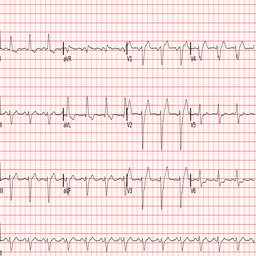

Imagem Transformada:


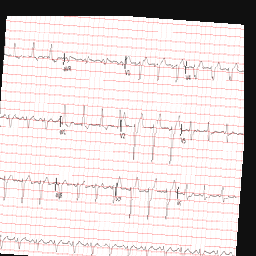

(3, 256, 256)
uint8
Imagem Original:


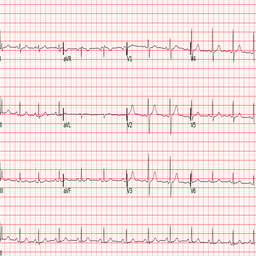

Imagem Transformada:


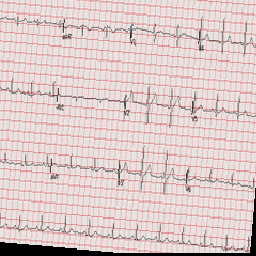

(3, 256, 256)
uint8
Imagem Original:


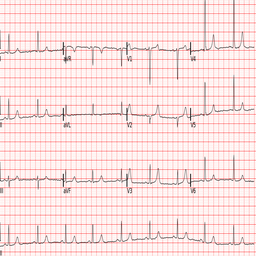

Imagem Transformada:


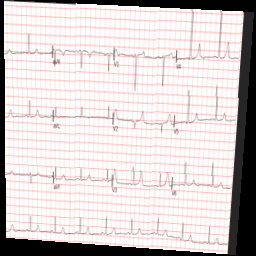

(3, 256, 256)
uint8
Imagem Original:


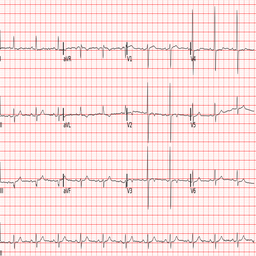

Imagem Transformada:


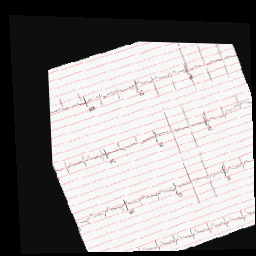

(3, 256, 256)
uint8
Imagem Original:


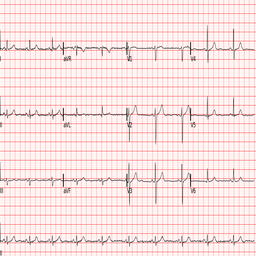

Imagem Transformada:


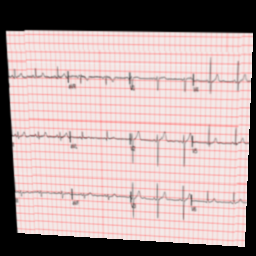

In [17]:
## crie uma transformacao de numpy para image pil e faca o display da imagem original e da imagem transformada para verificar se a transformacao esta correta
def numpy_to_pil(numpy_array):
    # Verifica se o array tem a forma correta (C, H, W)
   # if numpy_array.shape[0] != 3:
     #   raise ValueError("O array deve ter a forma (3, H, W) para ser convertido em imagem PIL.")

    print(numpy_array.shape)
    print(numpy_array.dtype)
    img_pil = Image.fromarray(numpy_array.transpose(1, 2, 0))  # Converte de (C, H, W) para (H, W, C)
    return (img_pil)

    return pil_image
for i in range(5):
    original_image = numpy_to_pil(img_dataset[i])
    transformed_image = transform(Image.fromarray(img_dataset[i].transpose(1, 2, 0)))
    print("Imagem Original:")
    display(original_image)
    print("Imagem Transformada:")
    display(transformed_image)


## Target Label

In [18]:
data['NORMAL'] =data['NORMAL'].map({True: 1, False: 0})
data['Other'] = data['Other'].map({True: 1, False: 0})
data['AFIB'] = data['AFIB'].map({True: 1, False: 0})

In [19]:
## concat labels NORMAL_LABEL, RITM_NAO_AFIB, AFIB em uma coluna chamada rotulo
# NORMAL','Other','AFIB'
data['rotulo'] = data['NORMAL'].astype(str)   + data['Other'].astype(str) + data['AFIB'].astype(str)

In [ ]:

data.query("rotulo == '000'")

,patient_id,path,age,sex,height,weight,AFIB,NORMAL,Other,rotulo


In [20]:
data['rotulo'].value_counts()

,count
rotulo,
100,16748
010,3542
001,1509


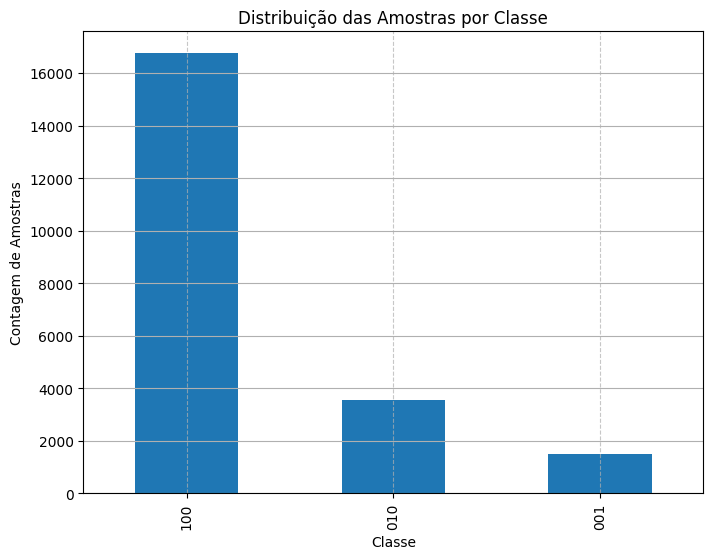

In [21]:
## Distribuicao das amostras
## Histograma da distribuicao das amostras
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
data['rotulo'].value_counts().plot(kind='bar')
plt.title('Distribuição das Amostras por Classe')
plt.xlabel('Classe')
plt.ylabel('Contagem de Amostras')
plt.grid(axis='y')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Kfold

In [ ]:
def a1():

    print(f"Configuracao do K-Fold para {folds} folds...")
    kf = KFold(n_splits=folds)
    kf.get_n_splits(tensor_imagem)
    print(kf)
    print("K-Fold configurado com sucesso.")

    print("Iniciando o treinamento com K-Fold Cross Validation...")

    train_loss_total = []
    val_loss_total =[]
    all_models =[]



## Class Weights

In [22]:
def class_weights(data_):
    """
    Calcula os pesos das classes com base na distribuição dos rótulos.

    Parâmetros:
        data_ (pd.DataFrame): DataFrame contendo a coluna 'rotulo'

    Retorna:
        torch.Tensor: Tensor contendo os pesos das classes
    """
    data_['class_weight'] = data_['rotulo'].map({'100':0,'010':1,'001':2})

    classes = ['NORMAL', 'Other', 'AFIB']
    y_train = data_['rotulo'].values
    # Conta quantas amostras existem por classe
    class_counts = np.bincount(data_['class_weight'], minlength=len(classes))

    # Evita divisão por zero
    class_counts = np.maximum(class_counts, 1)

    # Peso inverso da frequência
    class_weights = 1.0 / class_counts

    # Normaliza para não ficar exagerado
    class_weights = class_weights / class_weights.sum() * len(classes)

    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    print(f"Pesos das classes: Para classe NORMAL: {class_weights_tensor[0]}")
    print(f"Pesos das classes: Para classe Other: {class_weights_tensor[1]}")
    print(f"Pesos das classes: Para classe AFIB: {class_weights_tensor[2]}")
    print(f"Pesos das classes: {class_weights_tensor}")
    if (len(class_weights_tensor) != 3):
        raise ValueError(f"Erro: Esperado 3 pesos de classe, mas obtido {len(class_weights_tensor)}. Verifique os rótulos no DataFrame.")
    return class_weights_tensor


## Split Dataset To Test / Valid and Train

In [23]:
## Split Dataframe in test e train

def split_dataframe(dataframe, test_size=0.2, random_state=42, fold=None):
    """
    Divide um DataFrame em conjuntos de treino e teste.

    Parâmetros:
        dataframe (pd.DataFrame): DataFrame a ser dividido
        test_size (float): Proporção do conjunto de teste (default: 0.2)
        random_state (int): Semente para reprodutibilidade (default: 42)
        fold (int): Número da dobra (default: None)

    Retorna:
        tuple: (train_df, test_df)
    """
    # Verificar se o DataFrame não está vazio
    if dataframe.empty:
        raise ValueError("O DataFrame fornecido está vazio.")

    # Embaralhar o DataFrame
    shuffled_df = dataframe.sample(frac=1, random_state=random_state).reset_index(drop=True)

    # Calcular o índice de corte
    split_index = int(len(shuffled_df) * (1 - test_size))

    # Dividir em treino e teste
    train_df = shuffled_df.iloc[:split_index].reset_index(drop=True)
    test_df = shuffled_df.iloc[split_index:].reset_index(drop=True)

    print(f"✓ DataFrame dividido com sucesso:")
    print(f"  Total de amostras: {len(dataframe)}")
    print(f"  Conjunto de treino e validação: {len(train_df)} amostras")
    print(f"  Conjunto de teste: {len(test_df)} amostras")
    # write test_df to csv in path_out/output/test_df.csv
    path_out = ""
    test_df.to_csv(os.path.join(path_out,OUTPUT_TEST_PATH, f'test_df_{fold}.csv'), index=False)
    print(f"  Conjunto de teste salvo em: {os.path.join(path_out, 'saidas/output', f'test_df_{fold}.csv')}")
    print('Analise estatistica do conjunto de teste:')
    print(test_df['rotulo'].value_counts())
    print('Analise estatistica do conjunto de treino:')
    print(train_df['rotulo'].value_counts())
    return train_df, test_df

## Train Valid Loop with DataAug

In [24]:
print('''
      ###############################################
      Inicio do treinamento com K-Fold Cross Validation
      ###############################################
      ''')
device = 'cuda:0'
train_loss_total = []
val_loss_total =[]
multiplier_dataaug = 2
patient_id_list = data['patient_id'][0:N_samples].unique()
kf = KFold(n_splits=folds)
for i, (train_index, test_index) in enumerate(kf.split(patient_id_list)):
    print(f"Fold {i}:")
    #print(f"  Train: index={train_index}")
    #print(f"  Test:  index={test_index}")
    ## init train test for folder
    ## Load images from train test kf

    print(f"\n{'#'*80}")
    print(f"train e val split para fold {len(train_index)}  e {len(test_index)}...")
    #print(f'amostras {train_index}')
    ## Obter os patient_id para treino e validação
    ## Load images from dados_train e dados_val

    train_patient_ids = data.iloc[train_index]
    train_patient_ids = train_patient_ids['patient_id']

    dados_train = data[data['patient_id'].isin(train_patient_ids)][0:N_samples]
    dados_train, _ = split_dataframe(dados_train, test_size=0.2, random_state=42, fold=i)
    print(f"\n{'#'*80}")


    # dados_train em dados_train e dados_test com 20% para testes

    print(f"\n{'#'*80}")

    img_dataset_train, data_imgs, error_count = validate_and_load_images(
        data=dados_train[['patient_id','path', 'AFIB']],  # Seleciona apenas as colunas necessárias
        image_path_prefix=path,  # path definido anteriormente
        n_samples=N_samples,  # Carrega todas as amostras do conjunto de treino
        max_errors=10,
        type_load_img = 3
    )


    tensor_dataset_full_aug_train = data_augumentation(img_dataset_train, dados_train,multiplier_dataaug)
    ## Geracao do tensor de imagens

    print("Dataset de treino de dados (imagens + labels) criado com sucesso. Tamanho do Dataset:", len(tensor_dataset_full_aug_train))

    val_patient_ids = data.iloc[test_index]
    val_patient_ids = val_patient_ids['patient_id']

    dados_val = data[data['patient_id'].isin(val_patient_ids)][0:N_samples]
    print(path)
    img_dataset_val, data_imgs, error_count = validate_and_load_images(
        data=dados_val[['patient_id','path', 'AFIB']],  # Seleciona apenas as colunas necessárias
        image_path_prefix=path,  # path definido anteriormente
        n_samples=N_samples,
        max_errors=10,
        type_load_img = 3
    )
    tensor_dataset_valid = TensorDataset(torch.from_numpy(img_dataset_val), torch.from_numpy(np.array(dados_val[['NORMAL','Other','AFIB']].values, dtype=np.uint8)))
    #tensor_dataset_full_aug_val = data_augumentation(img_dataset_val, dados_val, 2)
    print("Dataset de validação de dados (imagens + labels) SEM DATAAUG criado com sucesso. Tamanho do Dataset:", len(img_dataset_val))

    ## Print com resumo dos dados utilizados para fold
    print(f"\n{'#'*80}")
    print(f"Resumo do Fold {i}:")
    print(f"  Tamanho do conjunto de treino: {len(tensor_dataset_full_aug_train)}")
    print(f"  Tamanho do conjunto de validação: {len(img_dataset_val)}")
    print(f"  Distribuição de labels no treino:\n{multiplier_dataaug*dados_train['rotulo'].value_counts()}")
    print(f"  Distribuição de labels na validação:\n{multiplier_dataaug*dados_val['rotulo'].value_counts()}")
    print(f"\n{'#'*80}")

    train_loader_img = DataLoader(tensor_dataset_full_aug_train, batch_size=BATCH_SIZE, shuffle=True)
    val_loader_img = DataLoader(tensor_dataset_valid, batch_size=BATCH_SIZE, shuffle=True)

    model= ECGClassifierResnet(num_classes=3)
    if (flg_salvar_modelos):
        salvar_model(model, path=OUTPUT_MODEL_PATH, name_file=f'model_fold_{i}.pth')
    print(f'Train and valid for Fold {i}')
    # Treina com Early Stopping (patience=5 épocas, delta=0.001)
    t, l,_,outputs,labels = simple_loop(model, train_loader_img, val_loader_img, epochs, batch_size=BATCH_SIZE, fold_index=i, patience=5, delta=0.0001, class_weights=class_weights(dados_train))
    ## Evaluate model.
    train_loss_total.append(t)
    val_loss_total.append(l)

print('''
      ###############################################
      Fim do treinamento com K-Fold Cross Validation
      ###############################################
      ''')
print("Treinamento com K-Fold Cross Validation concluído com sucesso.")


      ###############################################
      Inicio do treinamento com K-Fold Cross Validation
      ###############################################
      
Fold 0:

################################################################################
train e val split para fold 15095  e 3774...
✓ DataFrame dividido com sucesso:
  Total de amostras: 15280
  Conjunto de treino e validação: 12224 amostras
  Conjunto de teste: 3056 amostras
  Conjunto de teste salvo em: saidas/output/test_df_0.csv
Analise estatistica do conjunto de teste:
rotulo
100    2360
010     498
001     198
Name: count, dtype: int64
Analise estatistica do conjunto de treino:
rotulo
100    9399
010    1970
001     855
Name: count, dtype: int64

################################################################################

################################################################################

🖼️  VALIDAÇÃO E CARREGAMENTO DE IMAGENS

📌 Configuração:
  Amostras a processar: 12224
  Prefixo de ca

Carregando imagens: 100%|██████████| 12224/12224 [22:45<00:00,  8.95it/s]



✅ Carregamento concluído!
  Imagens carregadas com sucesso: 12224
  Imagens com erro: 0
  Shape final: (12224, 3, 256, 256)


Applying augmentation: 100%|██████████| 12224/12224 [03:09<00:00, 64.55it/s]


✓ Data augmentation completed for all images.
✓ Data augmentation aplicada. Novo shape do dataset: torch.Size([36672, 3, 256, 256]) no formato TensorDataset (imagens + labels)
Dataset de treino de dados (imagens + labels) criado com sucesso. Tamanho do Dataset: 36672
/content/content/drive/MyDrive/dataset_AFIB_Others/database_ptbxl/

🖼️  VALIDAÇÃO E CARREGAMENTO DE IMAGENS

📌 Configuração:
  Amostras a processar: 3856
  Prefixo de caminho: /content/content/drive/MyDrive/dataset_AFIB_Others/database_ptbxl/
  Máximo de erros permitidos: 10

💾 Memória disponível: 39.03 GB
  Memória estimada para imagens: 0.71 GB

🔄 Carregando imagens...


...


Epoch 2/50
Train Loss: 0.306127 | Train Acc: 0.7868 | Train F1: 0.8012
Val Loss:   0.287720 | Val Acc: 0.7995 | Val F1: 0.8178 | Precision: 0.8580 | Recall: 0.7995



Validation loop: 100%|██████████| 61/61 [00:15<00:00,  3.86it/s]



Epoch 3/50
Train Loss: 0.274418 | Train Acc: 0.8254 | Train F1: 0.8361
Val Loss:   0.275587 | Val Acc: 0.8344 | Val F1: 0.8441 | Precision: 0.8643 | Recall: 0.8344



Training loop:  25%|██▌       | 144/573 [02:14<06:41,  1.07it/s]


KeyboardInterrupt: 

In [ ]:
import numpy as np

arr = np.random.rand(10, 2, 3, 3)

multiplicador = 2

novo_arr = np.repeat(arr, multiplicador, axis=0)

print(novo_arr.shape)
# (20, 2, 3, 3)

(20, 2, 3, 3)


In [ ]:
path = 'dataset_AFIB_Others/data/'
STR_PATH = 'saida_123/saidas/'

## Avaliacao e Plots

In [ ]:
def calc_metrics():
    ## Visao geral de todas as metricas juntas para cada fold com subplots
    N_fold = 5
    criterio = nn.CrossEntropyLoss()
    for i in range(N_fold):
        df1_pred = np.float32(np.load(f'{STR_PATH}/output/metricas/valid/fold_{i}/predict_label_valid_fold_{i}.npy', allow_pickle=True))
        df1_true = np.float32(np.load(f'{STR_PATH}/output/metricas/valid/fold_{i}/true_label_valid_fold_{i}.npy', allow_pickle=True))
        df1_pred_train = np.float32(np.load(f'{STR_PATH}/output/metricas/train/fold_{i}/predict_label_train_fold_{i}.npy', allow_pickle=True))
        df1_true_train = np.float32(np.load(f'{STR_PATH}/output/metricas/train/fold_{i}/true_label_train_fold_{i}.npy', allow_pickle=True))

        total_loss = []
        total_acc = []
        total_acc_train = []
        total_loss_train = []
        total_f1 = []
        total_f1_train = []
        total_recall = []
        total_recall_train = []
        total_precision = []
        total_precision_train = []
        for j in range(len(df1_pred)):
            outputs_tensor = torch.tensor(df1_pred[j]).to(torch.float)
            labels_tensor = torch.tensor(df1_true[j]).to(torch.float)

            accuracy = torch.sum(outputs_tensor == labels_tensor).item() / len(labels_tensor) / len(labels_tensor[-1])
            total_acc.append(accuracy)
            outputs_tensor_train = torch.tensor(df1_pred_train[j]).to(torch.float)
            labels_tensor_train = torch.tensor(df1_true_train[j]).to(torch.float)
            accuracy_train = torch.sum(outputs_tensor_train == labels_tensor_train).item() / len(labels_tensor_train) / len(labels_tensor_train[-1])
            total_acc_train.append(accuracy_train)

            ## Loss calculo
            loss = criterio(outputs_tensor, labels_tensor)/32
            total_loss.append(loss.item())
            loss_train = criterio(outputs_tensor_train, labels_tensor_train)/32
            total_loss_train.append(loss_train.item())

            ## Recall e f1 score calculo
            # Convert predictions to binary labels using a threshold of 0.5
            predicted_labels = outputs_tensor.argmax(dim=1).cpu().numpy()
            true_labels = labels_tensor.argmax(dim=1).cpu().numpy()
            precision = precision_score(true_labels, predicted_labels, average='weighted')
            total_precision.append(precision)
            precision_train = precision_score(labels_tensor_train.argmax(dim=1).cpu().numpy(), outputs_tensor_train.argmax(dim=1).cpu().numpy(), average='weighted')
            total_precision_train.append(precision_train)

            ## Recall train valid
            recall = recall_score(true_labels, predicted_labels, average='micro')
            total_recall.append(recall)
            recall_train = recall_score(labels_tensor_train.argmax(dim=1).cpu().numpy(), outputs_tensor_train.argmax(dim=1).cpu().numpy(), average='micro')
            total_recall_train.append(recall_train)

            ## F1 score train valid
            f1 = f1_score(true_labels, predicted_labels, average='micro')
            total_f1.append(f1)
            f1_train = f1_score(labels_tensor_train.argmax(dim=1).cpu().numpy(), outputs_tensor_train.argmax(dim=1).cpu().numpy(), average='micro')
            total_f1_train.append(f1_train)
        # Create subplots for loss and accuracy
        plt.figure(figsize=(30, 20))
        plt.subplot(3, 3, 1)
        plt.plot(total_loss, marker='o', linestyle='-', linewidth=2, label='Validation Loss')
        plt.plot(total_loss_train, marker='x', linestyle='--', linewidth=2, label='Train Loss')
        plt.title(f'Fold {i} - Train and Validation Loss over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.subplot(3, 3, 2)
        plt.plot(total_acc, marker='o', linestyle='-', linewidth=2, label='Validation Accuracy')
        plt.plot(total_acc_train, marker='x', linestyle='--', linewidth=2, label='Train Accuracy')
        plt.title(f'Fold {i} - Train and Validation Accuracy over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Accuracy')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.subplot(3, 3, 3)
        plt.plot(total_f1, marker='o', linestyle='-', linewidth=2, label='Validation F1 Score')
        plt.plot(total_f1_train, marker='x', linestyle='--', linewidth=2, label='Train F1 Score')
        plt.title(f'Fold {i} - Train and Validation F1 Score over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('F1 Score')
        plt.grid(True, alpha=0.3)
        plt.legend()
        ## Add subplot for Precision and Recall
        plt.subplot(3, 3, 4)
        plt.plot(total_precision, marker='o', linestyle='-', linewidth=2, label='Validation Precision')
        plt.plot(total_precision_train, marker='x', linestyle='--', linewidth=2, label='Train Precision')

        plt.title(f'Fold {i} - Train and Validation Precision and Recall over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Precision / Recall')
        plt.grid(True, alpha=0.3)
        plt.legend()

        ## Recall subplot
        plt.subplot(3, 3, 5)
        plt.plot(total_recall, marker='o', linestyle='-', linewidth=2, label='Validation Recall')
        plt.plot(total_recall_train, marker='x', linestyle='--', linewidth=2, label='Train Recall')
        plt.title(f'Fold {i} - Train    and Validation Recall over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Recall')
        plt.grid(True, alpha=0.3)
        plt.legend()

        ## F1 Score subplot
        plt.subplot(3, 3, 6)
        plt.plot(total_f1, marker='o', linestyle='-', linewidth=2, label='Validation F1 Score')
        plt.plot(total_f1_train, marker='x', linestyle='--', linewidth=2, label='Train F1 Score')
        plt.title(f'Fold {i} - Train and Validation F1 Score over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('F1 Score')
        plt.grid(True, alpha=0.3)
        plt.legend()

        plt.show()

        print(f"Fold {i} - Mean Validation Loss: {np.mean(total_loss):.6f}, Std Validation Loss: {np.std(total_loss):.6f}")
        print(f"Fold {i} - Mean Train Loss: {np.mean(total_loss_train):.6f}, Std Train Loss: {np.std(total_loss_train):.6f}")
        print(f"Fold {i} - Mean Validation Accuracy: {np.mean(total_acc):.6f}, Std Validation Accuracy: {np.std(total_acc):.6f}")
        print(f"Fold {i} - Mean Train Accuracy: {np.mean(total_acc_train):.6f}, Std Train Accuracy: {np.std(total_acc_train):.6f}")
        print(f"Fold {i} - Mean Validation Precision: {np.mean(total_precision):.6f}, Std Validation Precision: {np.std(total_precision):.6f}")
        print(f"Fold {i} - Mean Train Precision: {np.mean(total_precision_train):.6f}, Std Train Precision: {np.std(total_precision_train):.6f}")
        print(f"Fold {i} - Mean Validation Recall: {np.mean(total_recall):.6f}, Std Validation Recall: {np.std(total_recall):.6f}")
        print(f"Fold {i} - Mean Train Recall: {np.mean(total_recall_train):.6f}, Std Train Recall: {np.std(total_recall_train):.6f}")
        print(f"Fold {i} - Mean Validation F1 Score: {np.mean(total_f1):.6f}, Std Validation F1 Score: {np.std(total_f1):.6f}")
        print(f"Fold {i} - Mean Train F1 Score: {np.mean(total_f1_train):.6f}, Std Train F1 Score: {np.std(total_f1_train):.6f}")

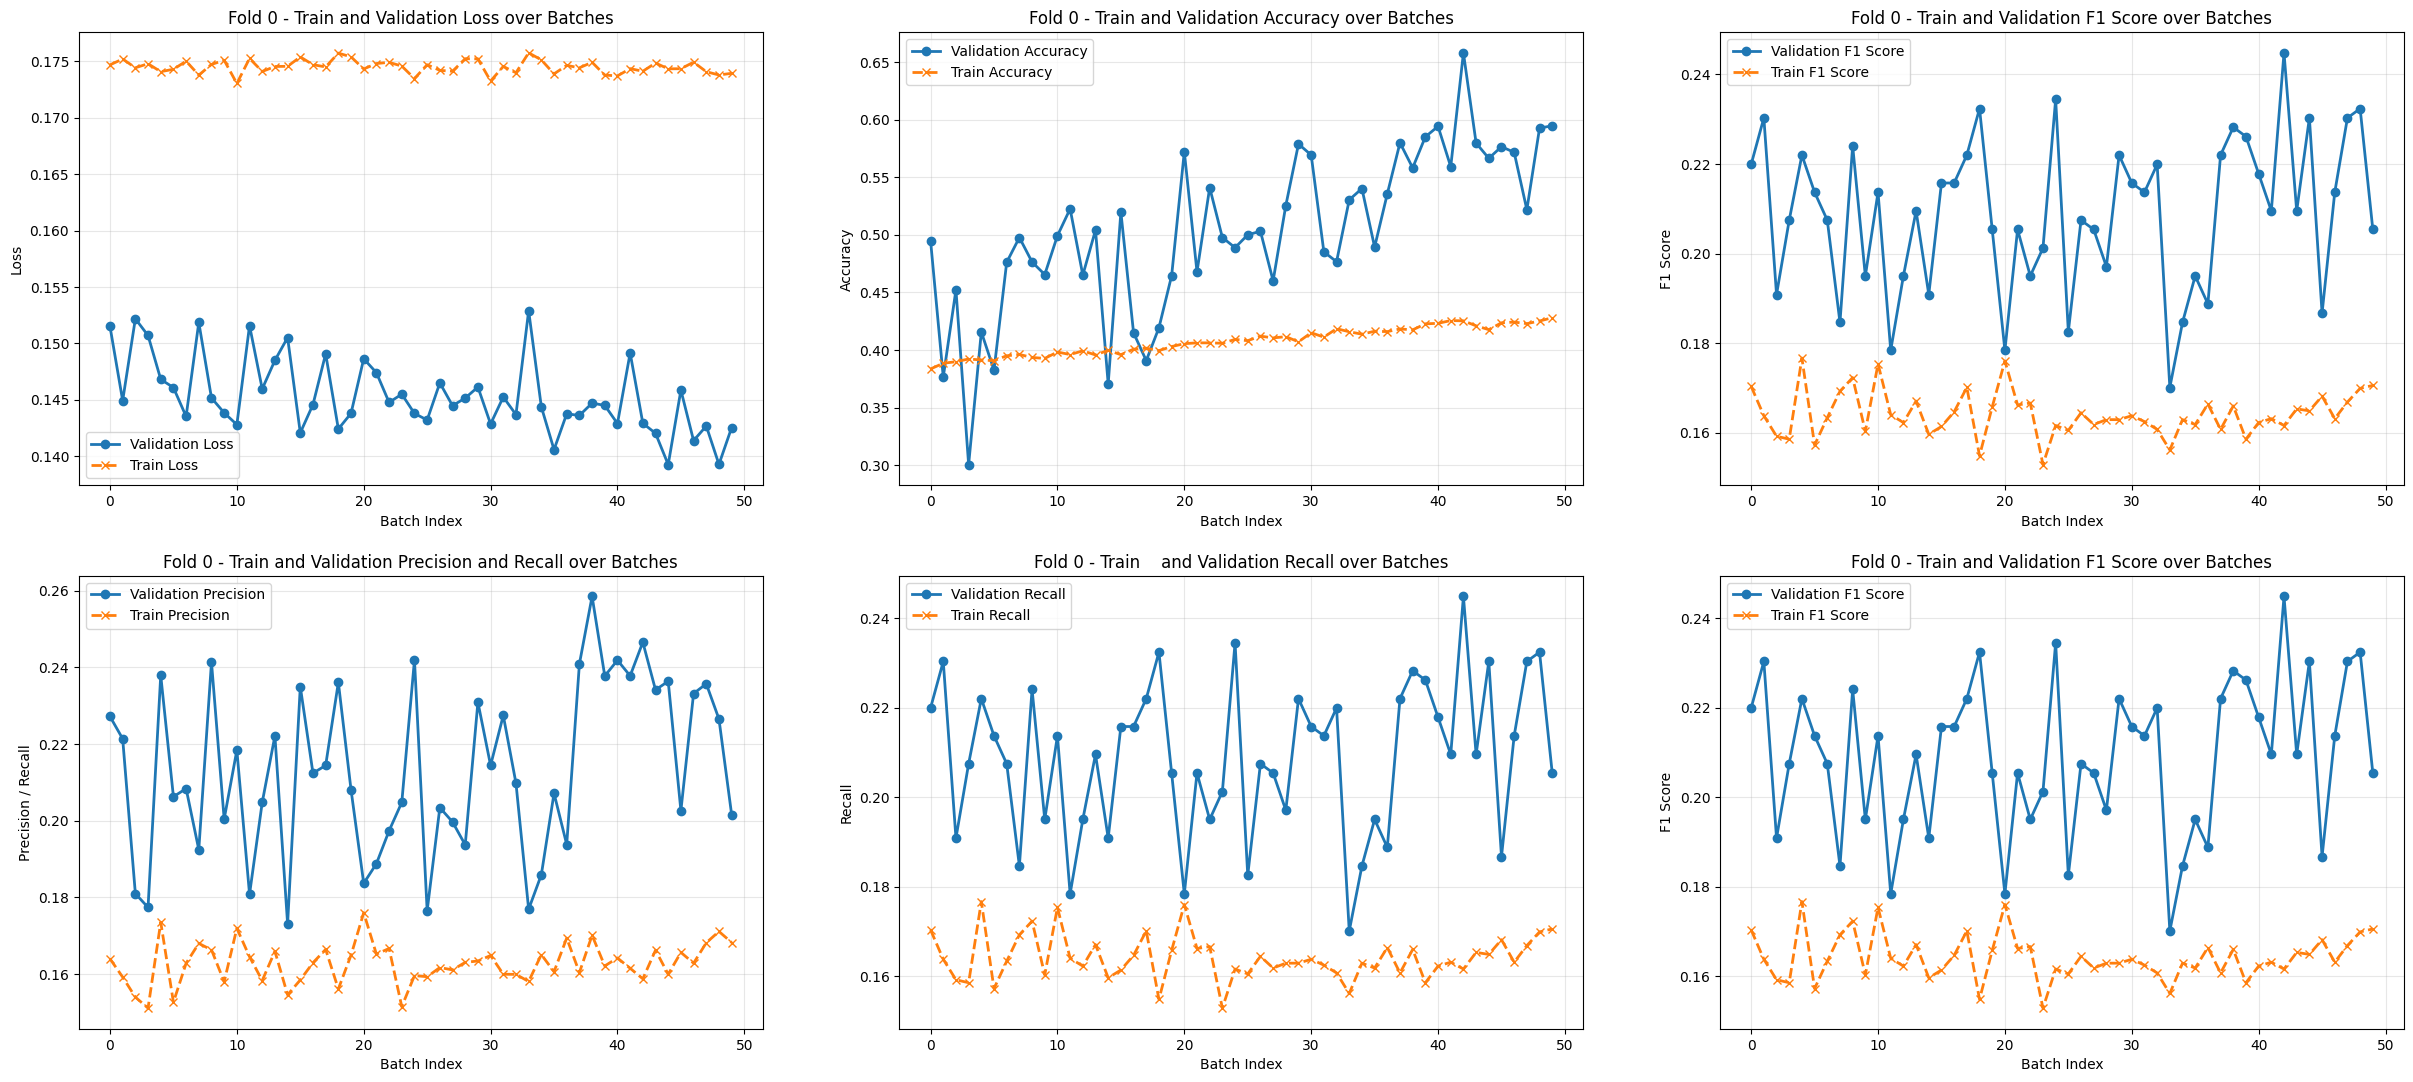

Fold 0 - Mean Validation Loss: 0.145355, Std Validation Loss: 0.003305
Fold 0 - Mean Train Loss: 0.174505, Std Train Loss: 0.000595
Fold 0 - Mean Validation Accuracy: 0.504155, Std Validation Accuracy: 0.070069
Fold 0 - Mean Train Accuracy: 0.407771, Std Train Accuracy: 0.011950
Fold 0 - Mean Validation Precision: 0.213349, Std Validation Precision: 0.022089
Fold 0 - Mean Train Precision: 0.162752, Std Train Precision: 0.005392
Fold 0 - Mean Validation Recall: 0.208963, Std Validation Recall: 0.016947
Fold 0 - Mean Train Recall: 0.164188, Std Train Recall: 0.005001
Fold 0 - Mean Validation F1 Score: 0.208963, Std Validation F1 Score: 0.016947
Fold 0 - Mean Train F1 Score: 0.164188, Std Train F1 Score: 0.005001


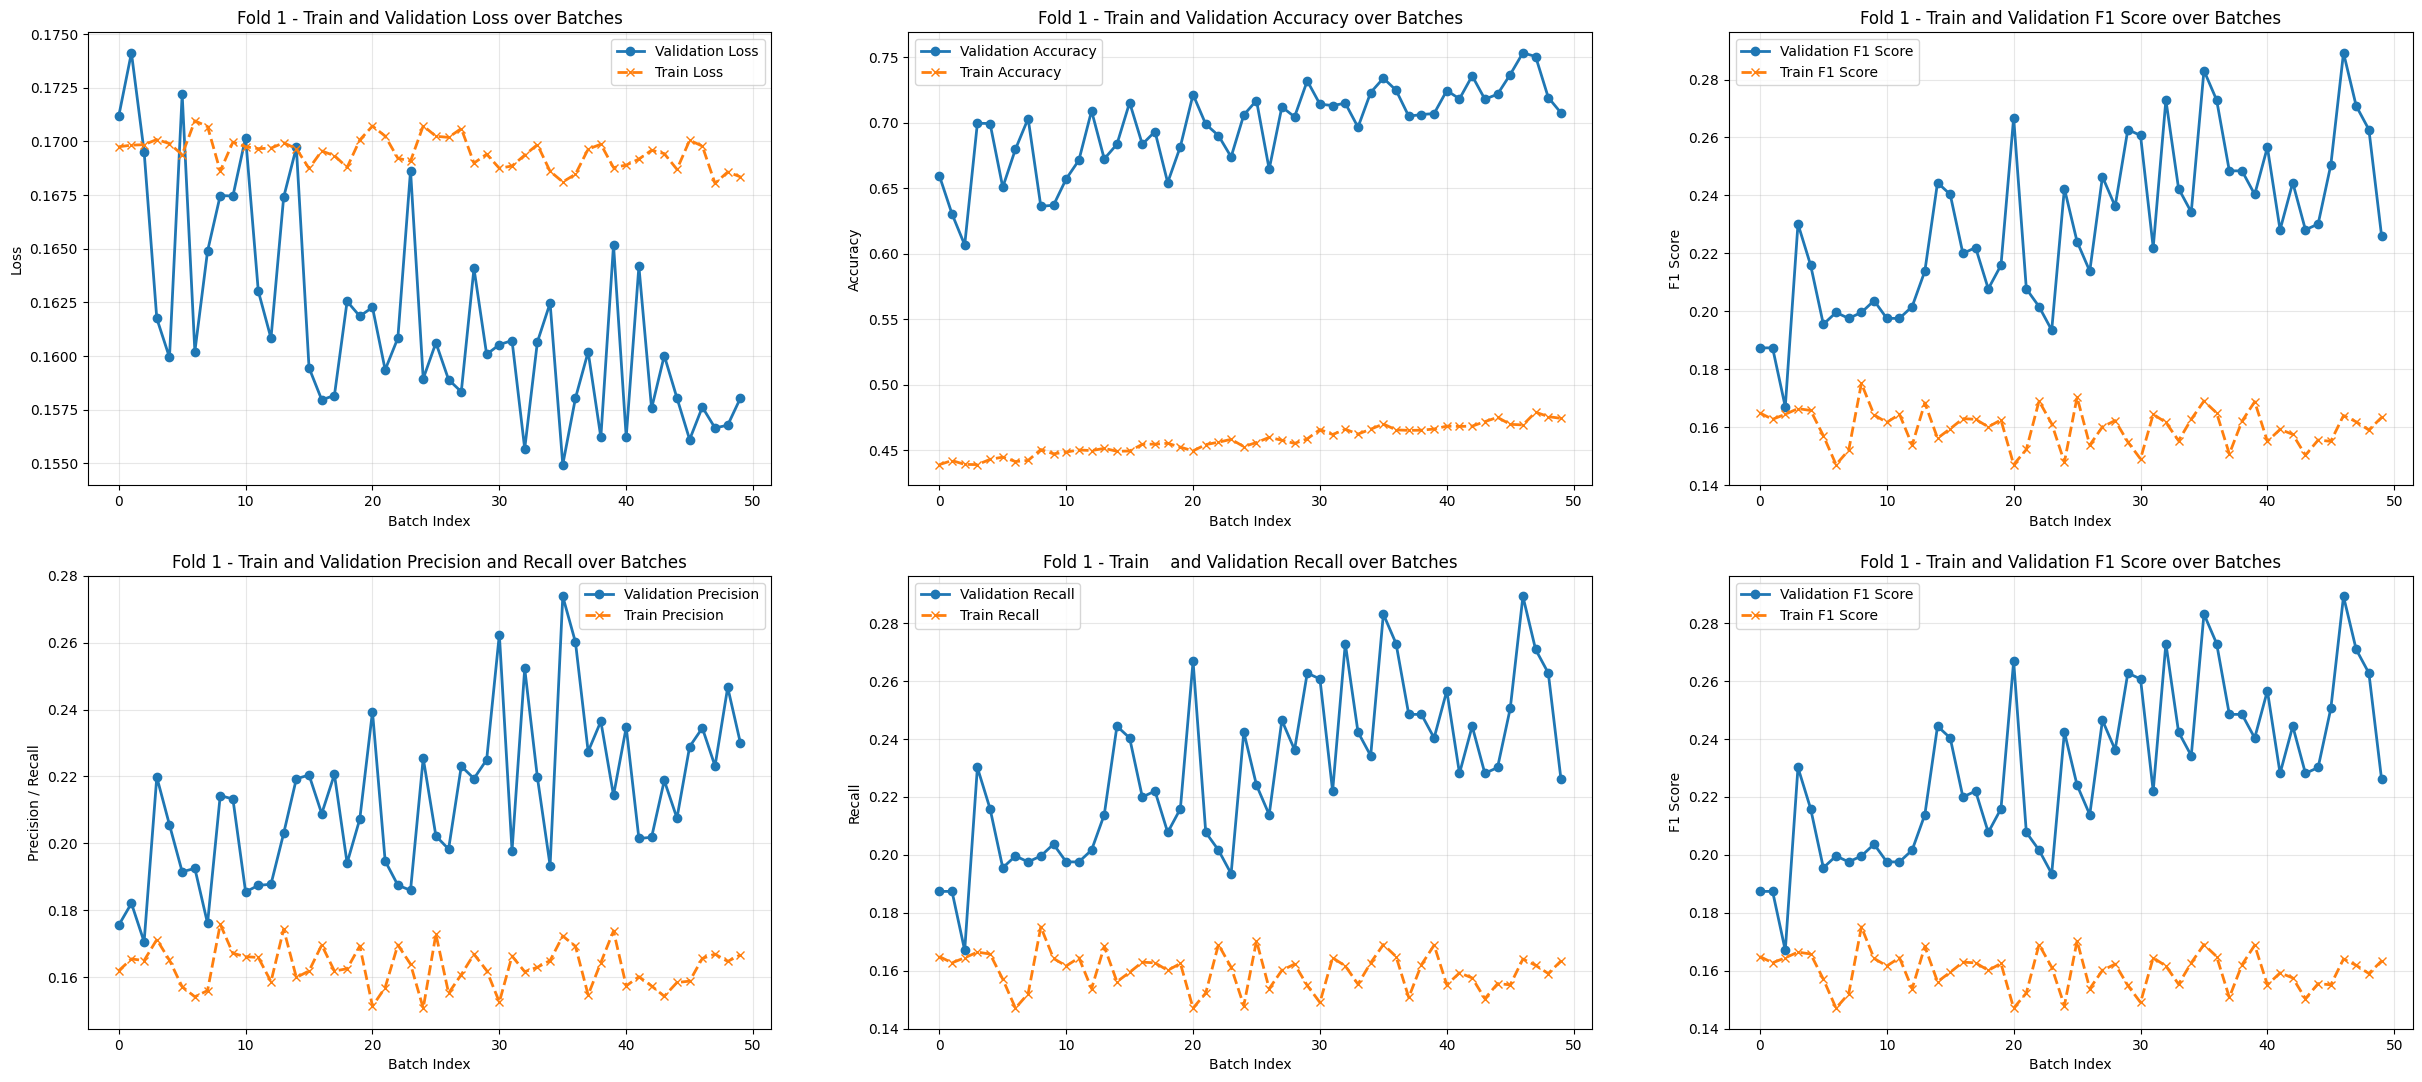

Fold 1 - Mean Validation Loss: 0.161753, Std Validation Loss: 0.004724
Fold 1 - Mean Train Loss: 0.169485, Std Train Loss: 0.000704
Fold 1 - Mean Validation Accuracy: 0.697357, Std Validation Accuracy: 0.031524
Fold 1 - Mean Train Accuracy: 0.457510, Std Train Accuracy: 0.010685
Fold 1 - Mean Validation Precision: 0.212837, Std Validation Precision: 0.023137
Fold 1 - Mean Train Precision: 0.163045, Std Train Precision: 0.006162
Fold 1 - Mean Validation Recall: 0.229043, Std Validation Recall: 0.027849
Fold 1 - Mean Train Recall: 0.160017, Std Train Recall: 0.006407
Fold 1 - Mean Validation F1 Score: 0.229043, Std Validation F1 Score: 0.027849
Fold 1 - Mean Train F1 Score: 0.160017, Std Train F1 Score: 0.006407


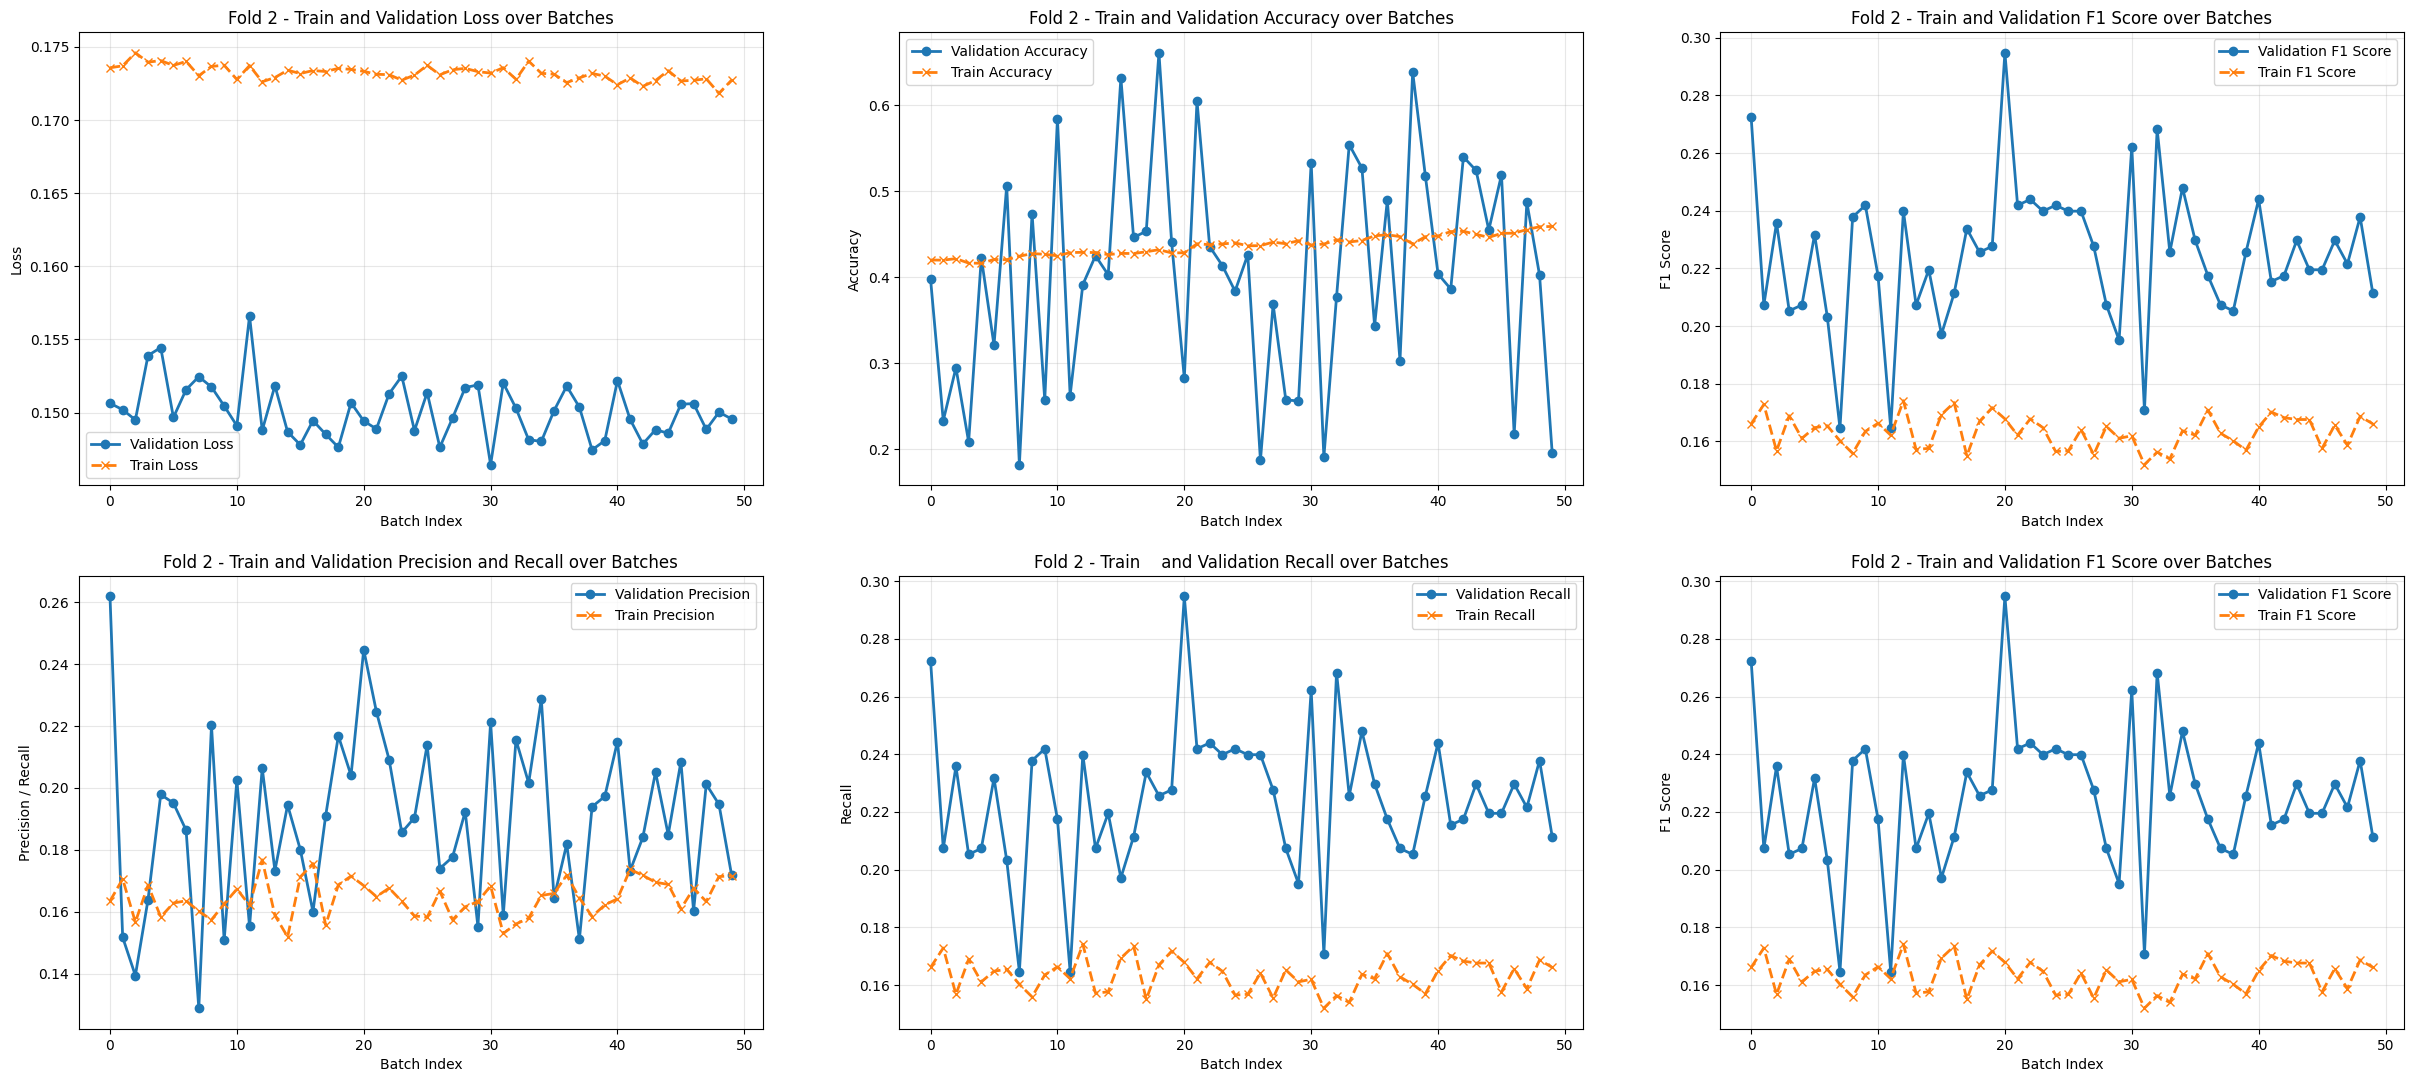

Fold 2 - Mean Validation Loss: 0.150122, Std Validation Loss: 0.001945
Fold 2 - Mean Train Loss: 0.173216, Std Train Loss: 0.000513
Fold 2 - Mean Validation Accuracy: 0.404477, Std Validation Accuracy: 0.128121
Fold 2 - Mean Train Accuracy: 0.436809, Std Train Accuracy: 0.011547
Fold 2 - Mean Validation Precision: 0.189188, Std Validation Precision: 0.026887
Fold 2 - Mean Train Precision: 0.164378, Std Train Precision: 0.005871
Fold 2 - Mean Validation Recall: 0.224593, Std Validation Recall: 0.024259
Fold 2 - Mean Train Recall: 0.163352, Std Train Recall: 0.005524
Fold 2 - Mean Validation F1 Score: 0.224593, Std Validation F1 Score: 0.024259
Fold 2 - Mean Train F1 Score: 0.163352, Std Train F1 Score: 0.005524


/home/leo/Documents/dev/oca-ia/afib_outros_normal/oca-ia/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leo/Documents/dev/oca-ia/afib_outros_normal/oca-ia/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


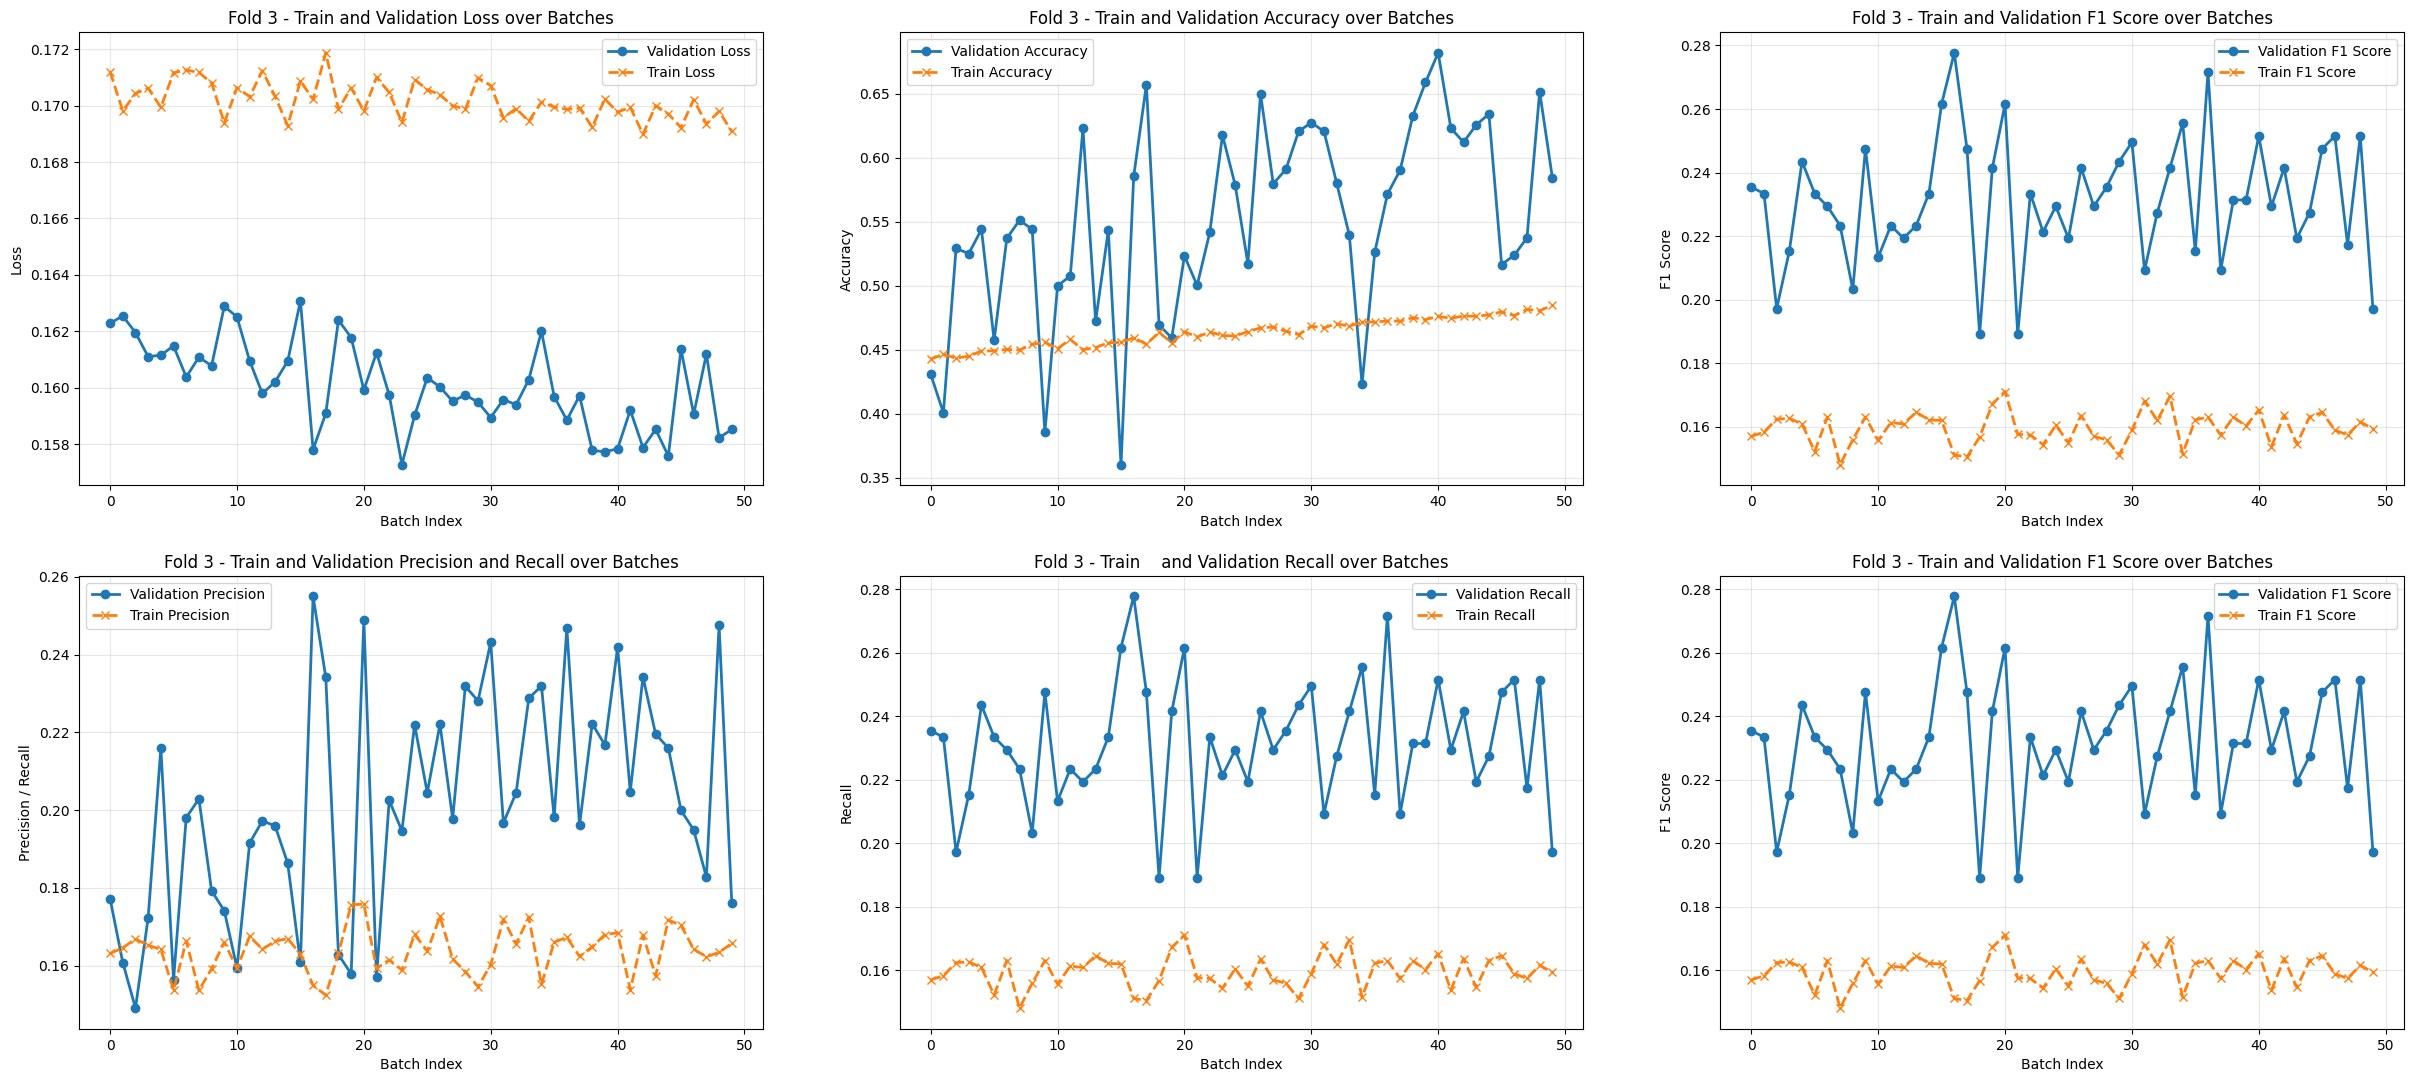

Fold 3 - Mean Validation Loss: 0.160072, Std Validation Loss: 0.001535
Fold 3 - Mean Train Loss: 0.170189, Std Train Loss: 0.000659
Fold 3 - Mean Validation Accuracy: 0.551308, Std Validation Accuracy: 0.075167
Fold 3 - Mean Train Accuracy: 0.463377, Std Train Accuracy: 0.011127
Fold 3 - Mean Validation Precision: 0.201963, Std Validation Precision: 0.028226
Fold 3 - Mean Train Precision: 0.163777, Std Train Precision: 0.005696
Fold 3 - Mean Validation Recall: 0.231429, Std Validation Recall: 0.019360
Fold 3 - Mean Train Recall: 0.159579, Std Train Recall: 0.005013
Fold 3 - Mean Validation F1 Score: 0.231429, Std Validation F1 Score: 0.019360
Fold 3 - Mean Train F1 Score: 0.159579, Std Train F1 Score: 0.005013


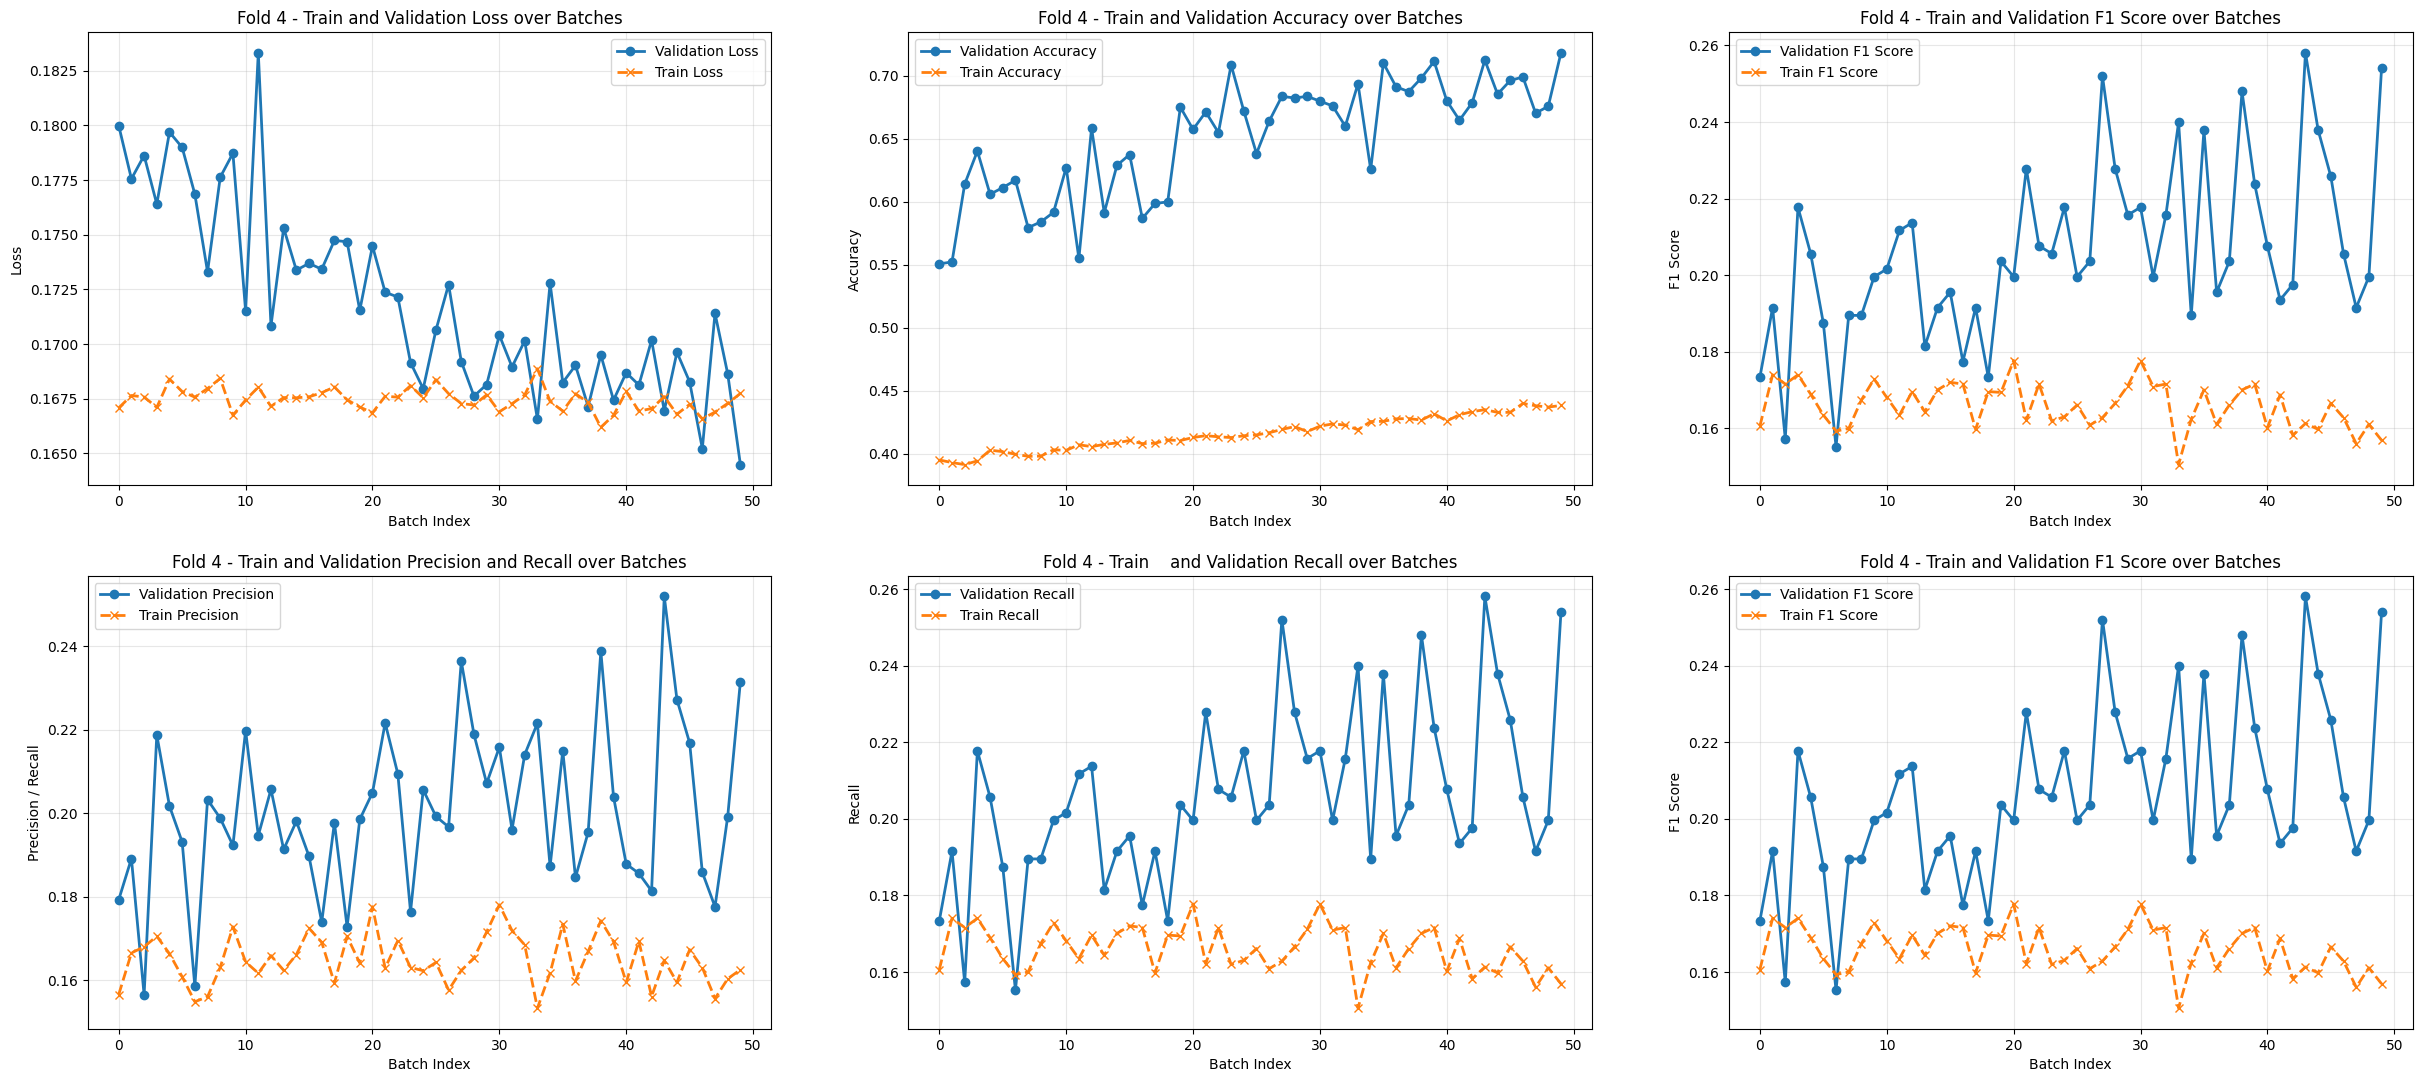

Fold 4 - Mean Validation Loss: 0.171929, Std Validation Loss: 0.004273
Fold 4 - Mean Train Loss: 0.167459, Std Train Loss: 0.000512
Fold 4 - Mean Validation Accuracy: 0.650570, Std Validation Accuracy: 0.045553
Fold 4 - Mean Train Accuracy: 0.416307, Std Train Accuracy: 0.013261
Fold 4 - Mean Validation Precision: 0.200519, Std Validation Precision: 0.019403
Fold 4 - Mean Train Precision: 0.164815, Std Train Precision: 0.005835
Fold 4 - Mean Validation Recall: 0.206169, Std Validation Recall: 0.022637
Fold 4 - Mean Train Recall: 0.165965, Std Train Recall: 0.005819
Fold 4 - Mean Validation F1 Score: 0.206169, Std Validation F1 Score: 0.022637
Fold 4 - Mean Train F1 Score: 0.165965, Std Train F1 Score: 0.005819


In [ ]:
calc_metrics()

In [ ]:
path = 'dataset_AFIB_Others/data/'
STR_PATH = 'saida_1234/saidas/'

In [ ]:
def calc_metrics():
    ## Visao geral de todas as metricas juntas para cada fold com subplots
    N_fold = 5
    criterio = nn.CrossEntropyLoss()
    for i in range(N_fold):
        df1_pred = np.float32(np.load(f'{STR_PATH}/output/metricas/valid/fold_{i}/predict_label_valid_fold_{i}.npy', allow_pickle=True))
        df1_true = np.float32(np.load(f'{STR_PATH}/output/metricas/valid/fold_{i}/true_label_valid_fold_{i}.npy', allow_pickle=True))
        df1_pred_train = np.float32(np.load(f'{STR_PATH}/output/metricas/train/fold_{i}/predict_label_train_fold_{i}.npy', allow_pickle=True))
        df1_true_train = np.float32(np.load(f'{STR_PATH}/output/metricas/train/fold_{i}/true_label_train_fold_{i}.npy', allow_pickle=True))

        total_loss = []
        total_acc = []
        total_acc_train = []
        total_loss_train = []
        total_f1 = []
        total_f1_train = []
        total_recall = []
        total_recall_train = []
        total_precision = []
        total_precision_train = []
        for j in range(len(df1_pred)):
            outputs_tensor = torch.tensor(df1_pred[j]).to(torch.float)
            labels_tensor = torch.tensor(df1_true[j]).to(torch.float)

            accuracy = torch.sum(outputs_tensor == labels_tensor).item() / len(labels_tensor) / len(labels_tensor[-1])
            total_acc.append(accuracy)
            outputs_tensor_train = torch.tensor(df1_pred_train[j]).to(torch.float)
            labels_tensor_train = torch.tensor(df1_true_train[j]).to(torch.float)
            accuracy_train = torch.sum(outputs_tensor_train == labels_tensor_train).item() / len(labels_tensor_train) / len(labels_tensor_train[-1])
            total_acc_train.append(accuracy_train)

            ## Loss calculo
            loss = criterio(outputs_tensor, labels_tensor)/32
            total_loss.append(loss.item())
            loss_train = criterio(outputs_tensor_train, labels_tensor_train)/32
            total_loss_train.append(loss_train.item())

            ## Recall e f1 score calculo
            # Convert predictions to binary labels using a threshold of 0.5
            predicted_labels = outputs_tensor.argmax(dim=1).cpu().numpy()
            true_labels = labels_tensor.argmax(dim=1).cpu().numpy()
            precision = precision_score(true_labels, predicted_labels, average='weighted')
            total_precision.append(precision)
            precision_train = precision_score(labels_tensor_train.argmax(dim=1).cpu().numpy(), outputs_tensor_train.argmax(dim=1).cpu().numpy(), average='weighted')
            total_precision_train.append(precision_train)

            ## Recall train valid
            recall = recall_score(true_labels, predicted_labels, average='micro')
            total_recall.append(recall)
            recall_train = recall_score(labels_tensor_train.argmax(dim=1).cpu().numpy(), outputs_tensor_train.argmax(dim=1).cpu().numpy(), average='micro')
            total_recall_train.append(recall_train)

            ## F1 score train valid
            f1 = f1_score(true_labels, predicted_labels, average='micro')
            total_f1.append(f1)
            f1_train = f1_score(labels_tensor_train.argmax(dim=1).cpu().numpy(), outputs_tensor_train.argmax(dim=1).cpu().numpy(), average='micro')
            total_f1_train.append(f1_train)
        # Create subplots for loss and accuracy
        plt.figure(figsize=(30, 20))
        plt.subplot(3, 3, 1)
        plt.plot(total_loss, marker='o', linestyle='-', linewidth=2, label='Validation Loss')
        plt.plot(total_loss_train, marker='x', linestyle='--', linewidth=2, label='Train Loss')
        plt.title(f'Fold {i} - Train and Validation Loss over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.subplot(3, 3, 2)
        plt.plot(total_acc, marker='o', linestyle='-', linewidth=2, label='Validation Accuracy')
        plt.plot(total_acc_train, marker='x', linestyle='--', linewidth=2, label='Train Accuracy')
        plt.title(f'Fold {i} - Train and Validation Accuracy over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Accuracy')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.subplot(3, 3, 3)
        plt.plot(total_f1, marker='o', linestyle='-', linewidth=2, label='Validation F1 Score')
        plt.plot(total_f1_train, marker='x', linestyle='--', linewidth=2, label='Train F1 Score')
        plt.title(f'Fold {i} - Train and Validation F1 Score over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('F1 Score')
        plt.grid(True, alpha=0.3)
        plt.legend()
        ## Add subplot for Precision and Recall
        plt.subplot(3, 3, 4)
        plt.plot(total_precision, marker='o', linestyle='-', linewidth=2, label='Validation Precision')
        plt.plot(total_precision_train, marker='x', linestyle='--', linewidth=2, label='Train Precision')

        plt.title(f'Fold {i} - Train and Validation Precision and Recall over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Precision / Recall')
        plt.grid(True, alpha=0.3)
        plt.legend()

        ## Recall subplot
        plt.subplot(3, 3, 5)
        plt.plot(total_recall, marker='o', linestyle='-', linewidth=2, label='Validation Recall')
        plt.plot(total_recall_train, marker='x', linestyle='--', linewidth=2, label='Train Recall')
        plt.title(f'Fold {i} - Train    and Validation Recall over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Recall')
        plt.grid(True, alpha=0.3)
        plt.legend()

        ## F1 Score subplot
        plt.subplot(3, 3, 6)
        plt.plot(total_f1, marker='o', linestyle='-', linewidth=2, label='Validation F1 Score')
        plt.plot(total_f1_train, marker='x', linestyle='--', linewidth=2, label='Train F1 Score')
        plt.title(f'Fold {i} - Train and Validation F1 Score over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('F1 Score')
        plt.grid(True, alpha=0.3)
        plt.legend()

        plt.show()

        print(f"Fold {i} - Mean Validation Loss: {np.mean(total_loss):.6f}, Std Validation Loss: {np.std(total_loss):.6f}")
        print(f"Fold {i} - Mean Train Loss: {np.mean(total_loss_train):.6f}, Std Train Loss: {np.std(total_loss_train):.6f}")
        print(f"Fold {i} - Mean Validation Accuracy: {np.mean(total_acc):.6f}, Std Validation Accuracy: {np.std(total_acc):.6f}")
        print(f"Fold {i} - Mean Train Accuracy: {np.mean(total_acc_train):.6f}, Std Train Accuracy: {np.std(total_acc_train):.6f}")
        print(f"Fold {i} - Mean Validation Precision: {np.mean(total_precision):.6f}, Std Validation Precision: {np.std(total_precision):.6f}")
        print(f"Fold {i} - Mean Train Precision: {np.mean(total_precision_train):.6f}, Std Train Precision: {np.std(total_precision_train):.6f}")
        print(f"Fold {i} - Mean Validation Recall: {np.mean(total_recall):.6f}, Std Validation Recall: {np.std(total_recall):.6f}")
        print(f"Fold {i} - Mean Train Recall: {np.mean(total_recall_train):.6f}, Std Train Recall: {np.std(total_recall_train):.6f}")
        print(f"Fold {i} - Mean Validation F1 Score: {np.mean(total_f1):.6f}, Std Validation F1 Score: {np.std(total_f1):.6f}")
        print(f"Fold {i} - Mean Train F1 Score: {np.mean(total_f1_train):.6f}, Std Train F1 Score: {np.std(total_f1_train):.6f}")

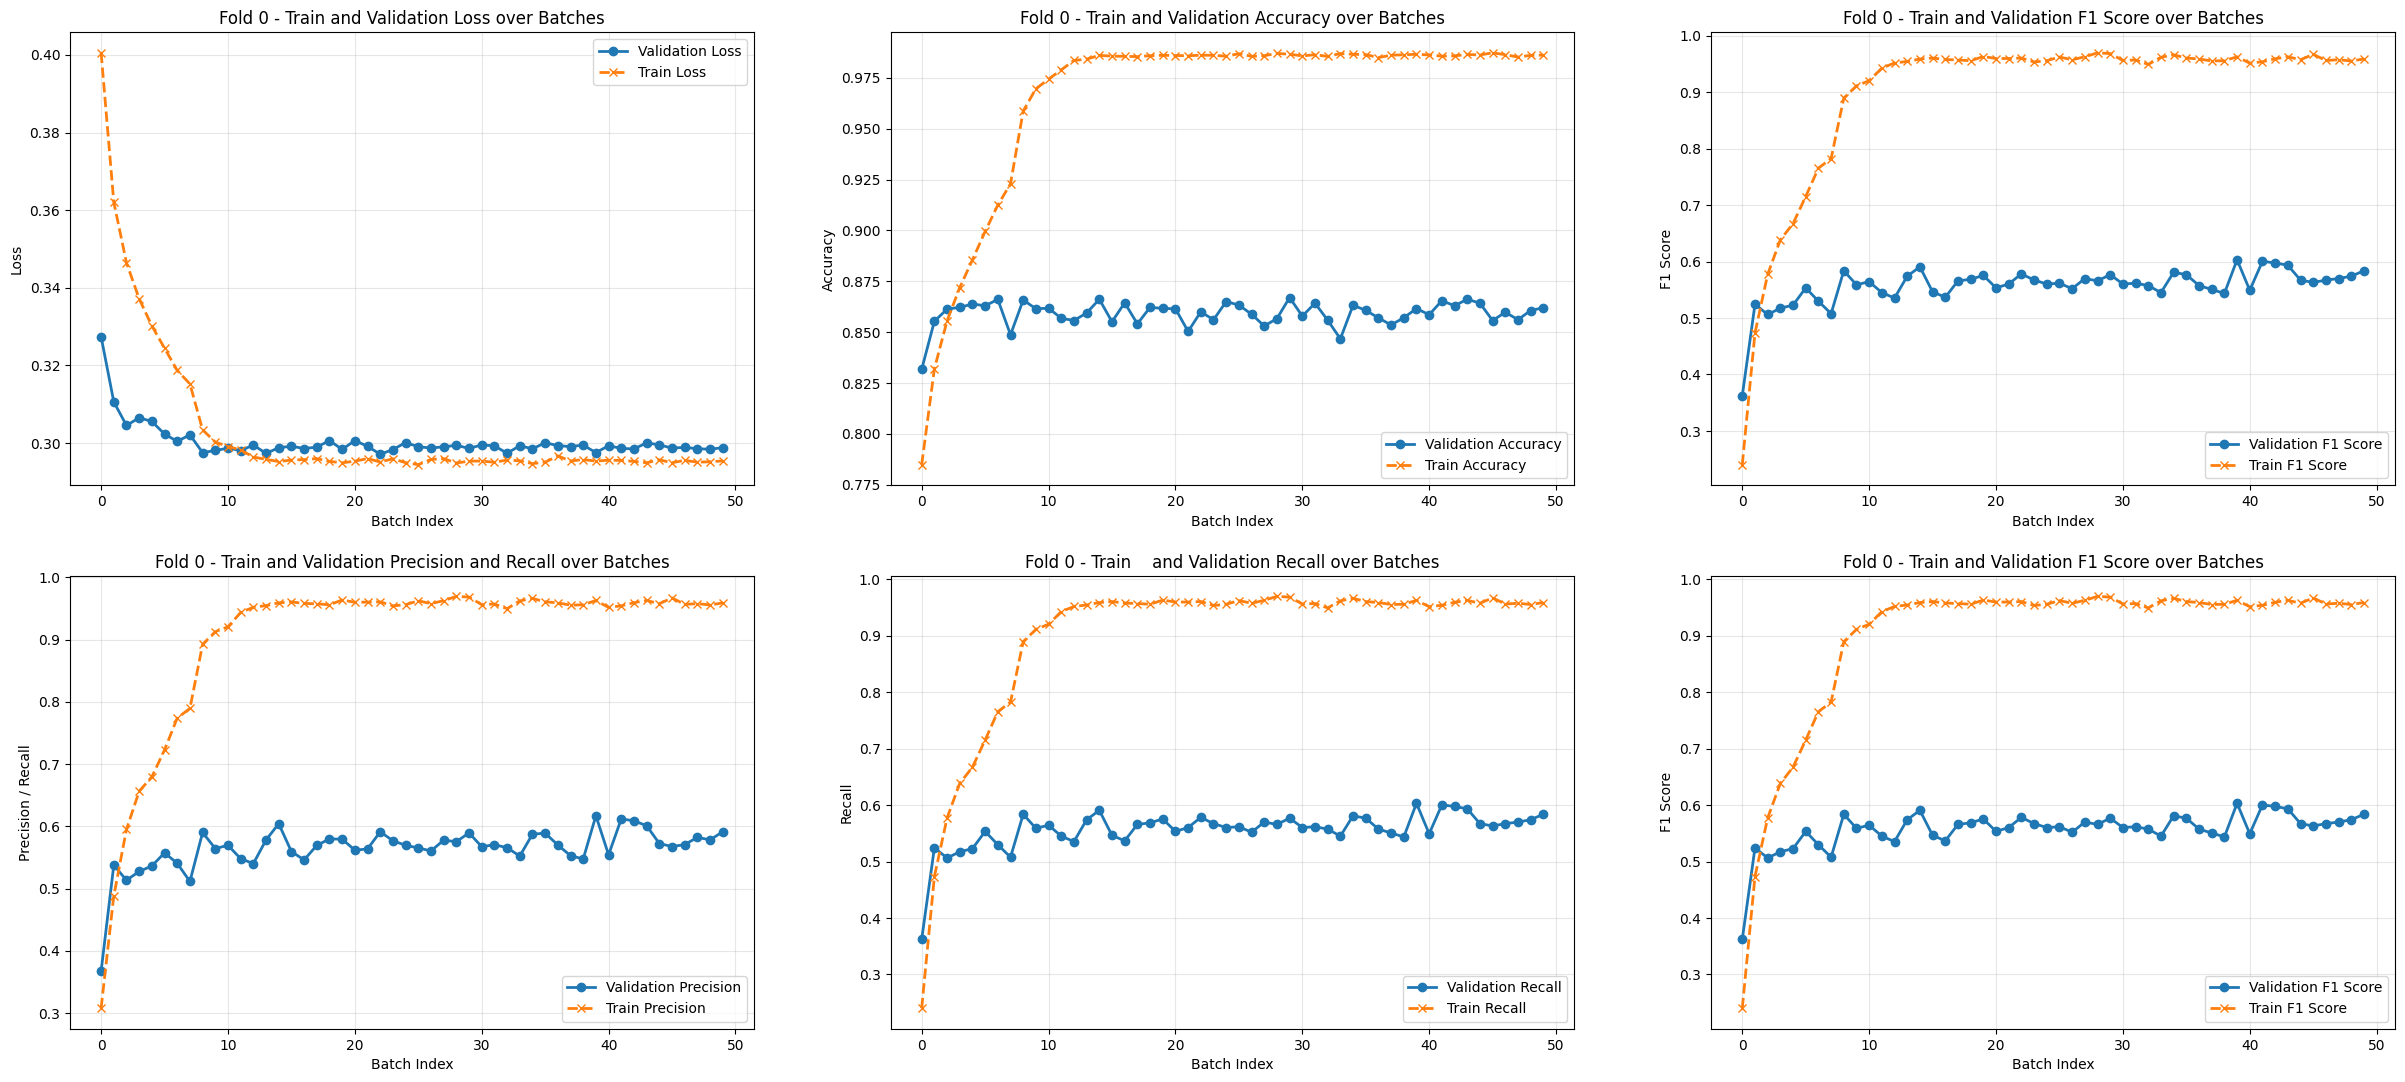

Fold 0 - Mean Validation Loss: 0.300217, Std Validation Loss: 0.004573
Fold 0 - Mean Train Loss: 0.303212, Std Train Loss: 0.019945
Fold 0 - Mean Validation Accuracy: 0.859182, Std Validation Accuracy: 0.006088
Fold 0 - Mean Train Accuracy: 0.966302, Std Train Accuracy: 0.045374
Fold 0 - Mean Validation Precision: 0.564146, Std Validation Precision: 0.036169
Fold 0 - Mean Train Precision: 0.902556, Std Train Precision: 0.135382
Fold 0 - Mean Validation Recall: 0.556266, Std Validation Recall: 0.035318
Fold 0 - Mean Train Recall: 0.898901, Std Train Recall: 0.144458
Fold 0 - Mean Validation F1 Score: 0.556266, Std Validation F1 Score: 0.035318
Fold 0 - Mean Train F1 Score: 0.898901, Std Train F1 Score: 0.144458


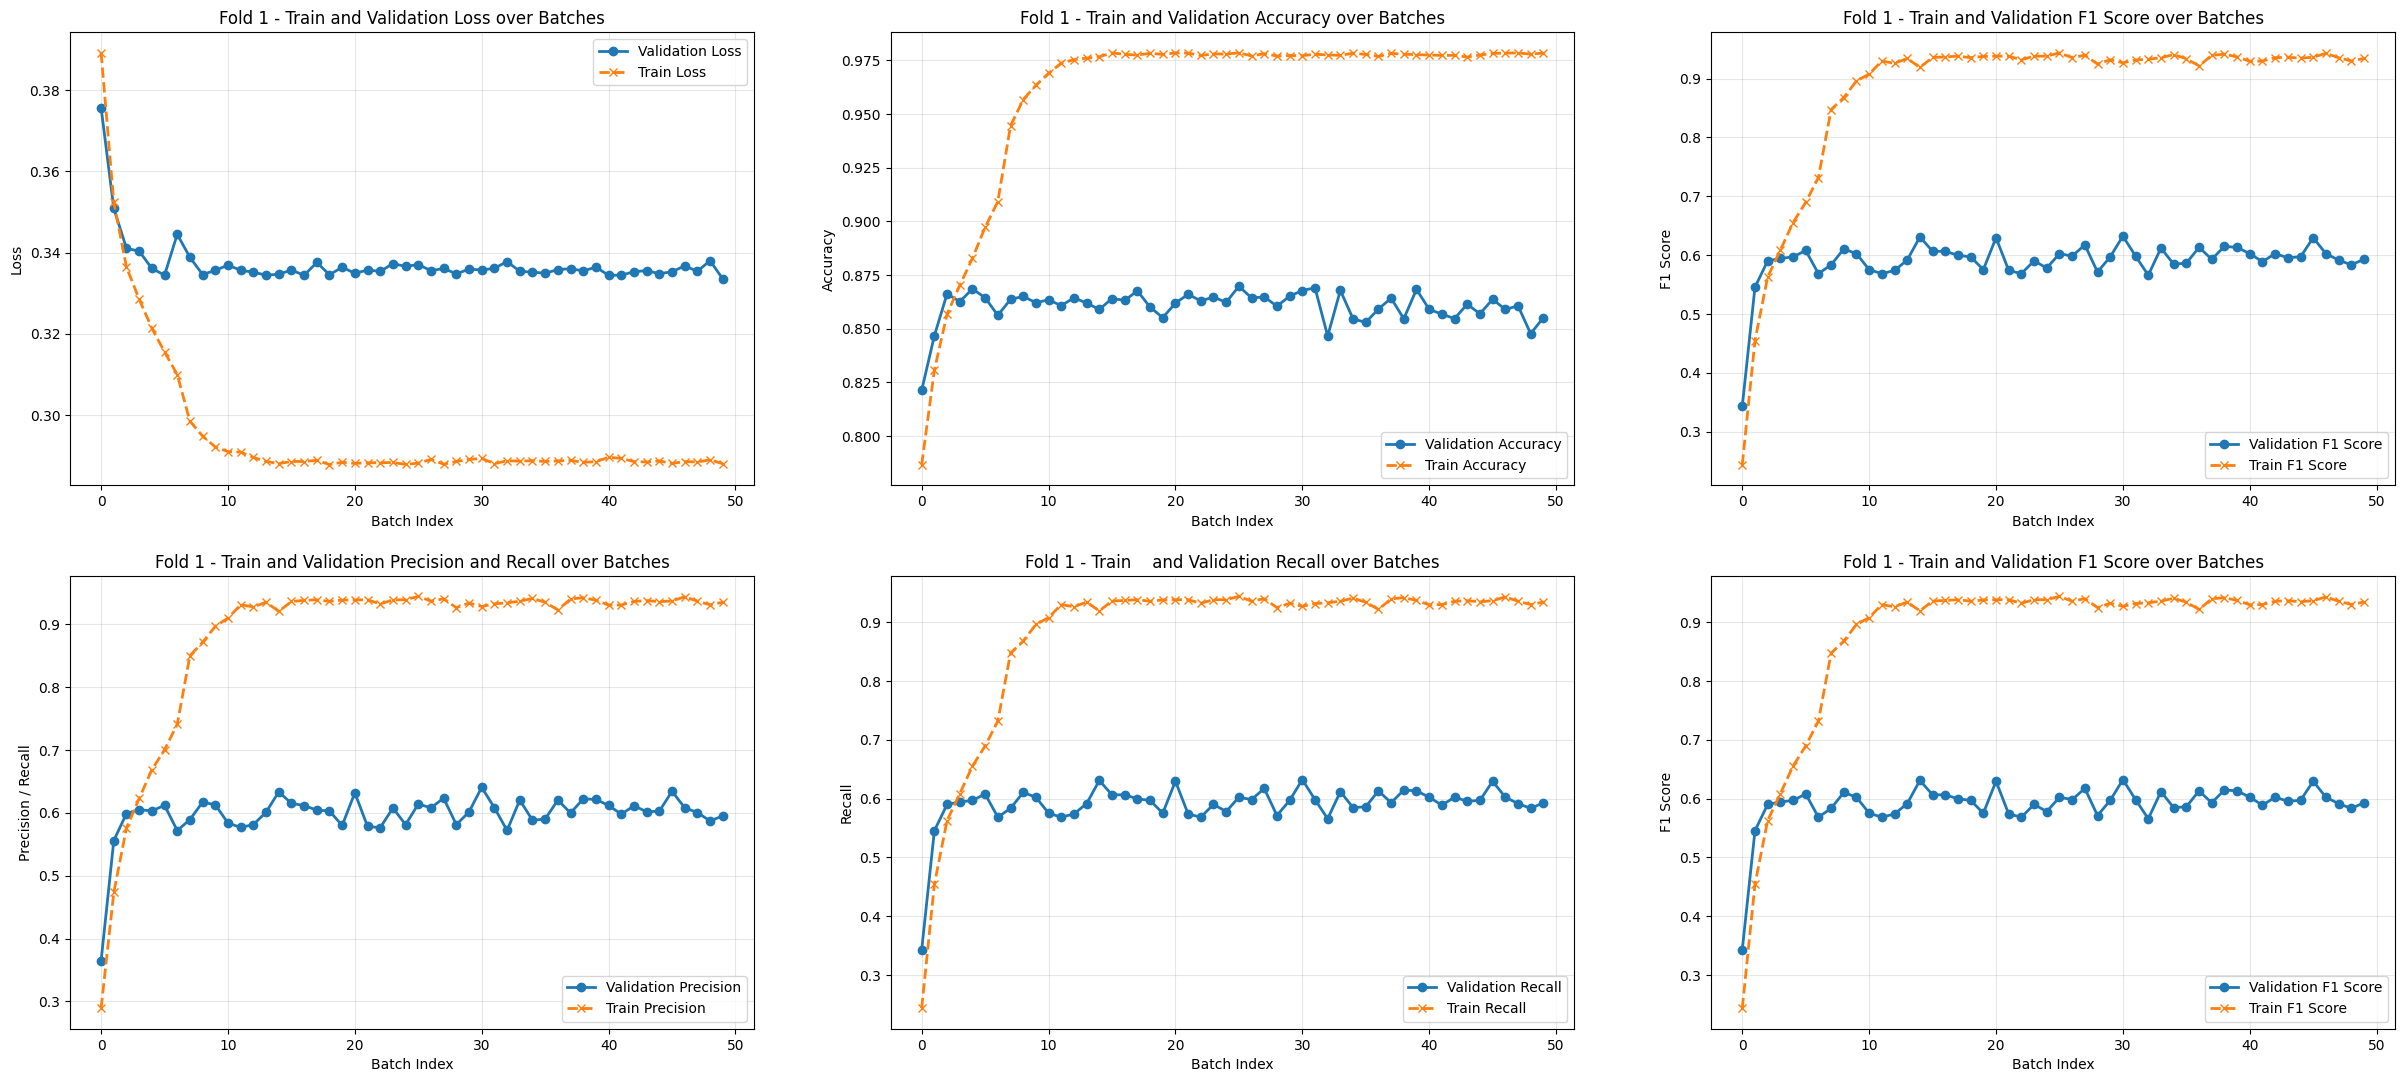

Fold 1 - Mean Validation Loss: 0.337200, Std Validation Loss: 0.006165
Fold 1 - Mean Train Loss: 0.295708, Std Train Loss: 0.018965
Fold 1 - Mean Validation Accuracy: 0.860390, Std Validation Accuracy: 0.007833
Fold 1 - Mean Train Accuracy: 0.959833, Std Train Accuracy: 0.042497
Fold 1 - Mean Validation Precision: 0.597132, Std Validation Precision: 0.037793
Fold 1 - Mean Train Precision: 0.881608, Std Train Precision: 0.133574
Fold 1 - Mean Validation Recall: 0.589905, Std Validation Recall: 0.039619
Fold 1 - Mean Train Recall: 0.878227, Std Train Recall: 0.140554
Fold 1 - Mean Validation F1 Score: 0.589905, Std Validation F1 Score: 0.039619
Fold 1 - Mean Train F1 Score: 0.878227, Std Train F1 Score: 0.140554


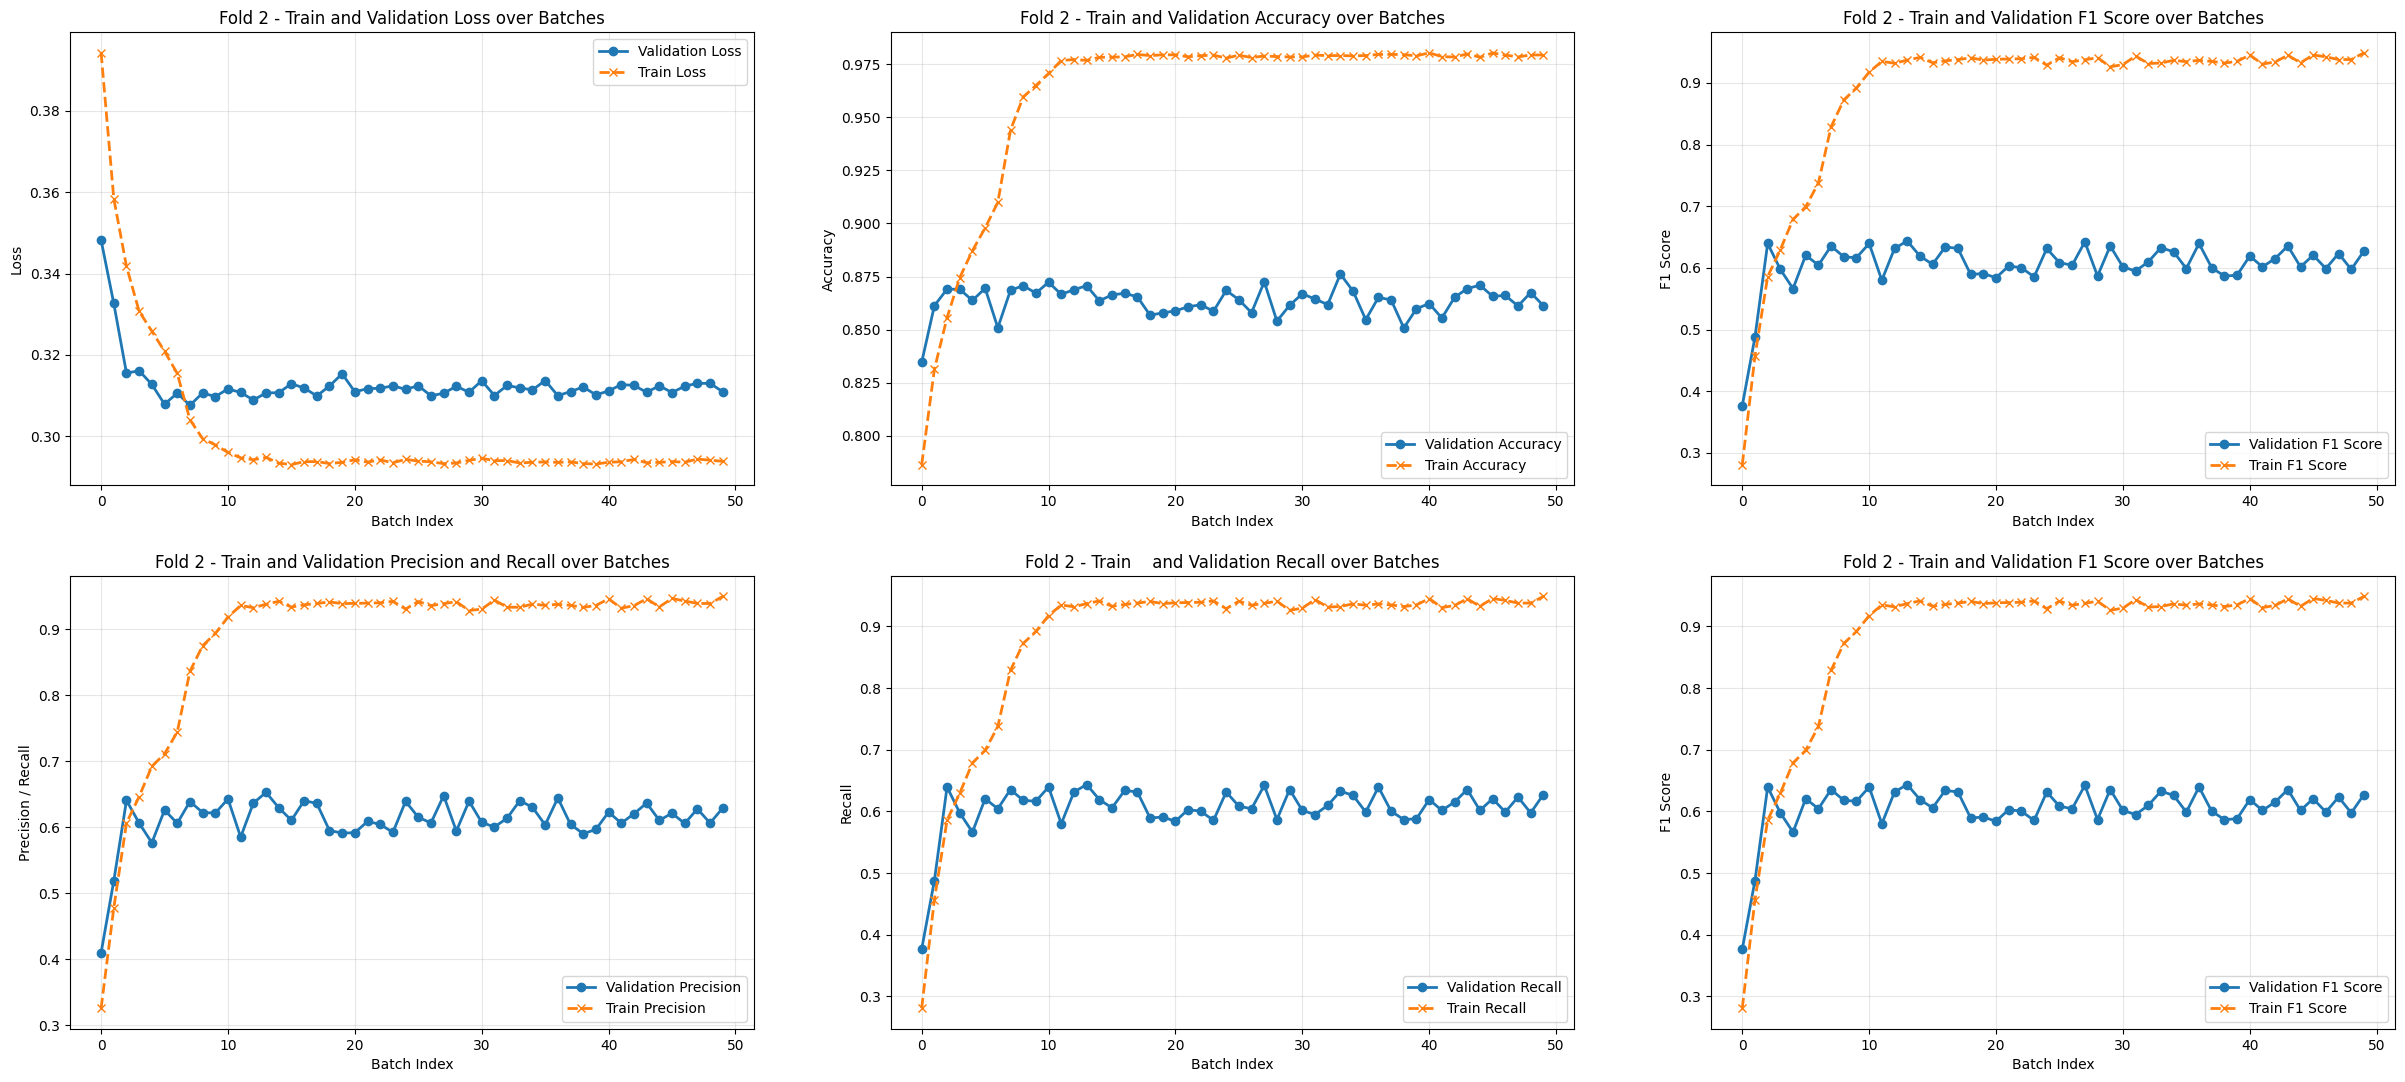

Fold 2 - Mean Validation Loss: 0.312744, Std Validation Loss: 0.006084
Fold 2 - Mean Train Loss: 0.300865, Std Train Loss: 0.018877
Fold 2 - Mean Validation Accuracy: 0.863504, Std Validation Accuracy: 0.006920
Fold 2 - Mean Train Accuracy: 0.961182, Std Train Accuracy: 0.042621
Fold 2 - Mean Validation Precision: 0.610700, Std Validation Precision: 0.036847
Fold 2 - Mean Train Precision: 0.886237, Std Train Precision: 0.127696
Fold 2 - Mean Validation Recall: 0.604580, Std Validation Recall: 0.041508
Fold 2 - Mean Train Recall: 0.882414, Std Train Recall: 0.135068
Fold 2 - Mean Validation F1 Score: 0.604580, Std Validation F1 Score: 0.041508
Fold 2 - Mean Train F1 Score: 0.882414, Std Train F1 Score: 0.135068


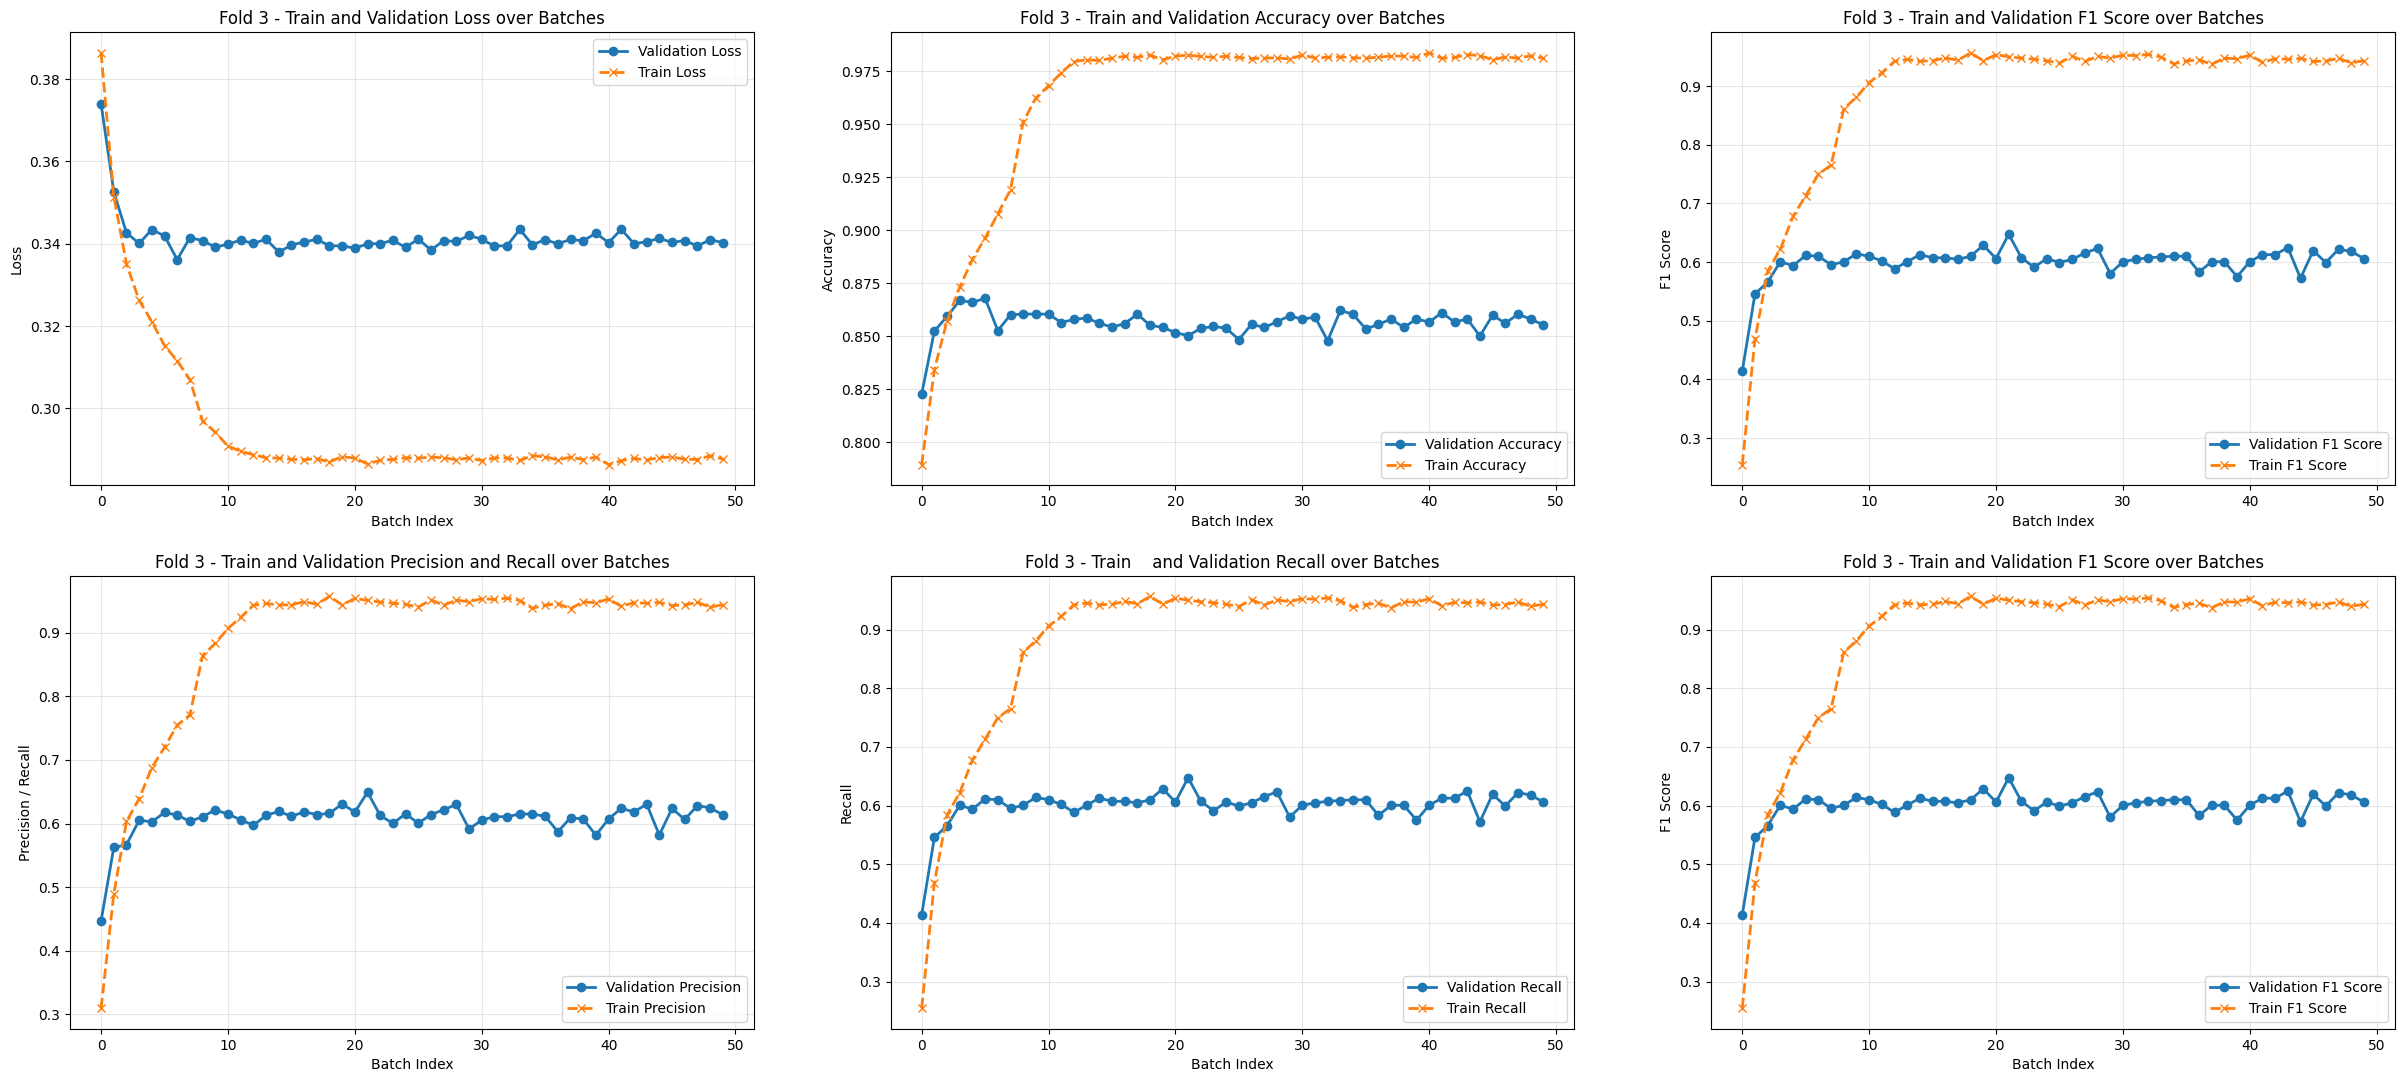

Fold 3 - Mean Validation Loss: 0.341377, Std Validation Loss: 0.005126
Fold 3 - Mean Train Loss: 0.295195, Std Train Loss: 0.018801
Fold 3 - Mean Validation Accuracy: 0.856351, Std Validation Accuracy: 0.006322
Fold 3 - Mean Train Accuracy: 0.962404, Std Train Accuracy: 0.043508
Fold 3 - Mean Validation Precision: 0.607087, Std Validation Precision: 0.027468
Fold 3 - Mean Train Precision: 0.890482, Std Train Precision: 0.131874
Fold 3 - Mean Validation Recall: 0.599786, Std Validation Recall: 0.031102
Fold 3 - Mean Train Recall: 0.887054, Std Train Recall: 0.139996
Fold 3 - Mean Validation F1 Score: 0.599786, Std Validation F1 Score: 0.031102
Fold 3 - Mean Train F1 Score: 0.887054, Std Train F1 Score: 0.139996


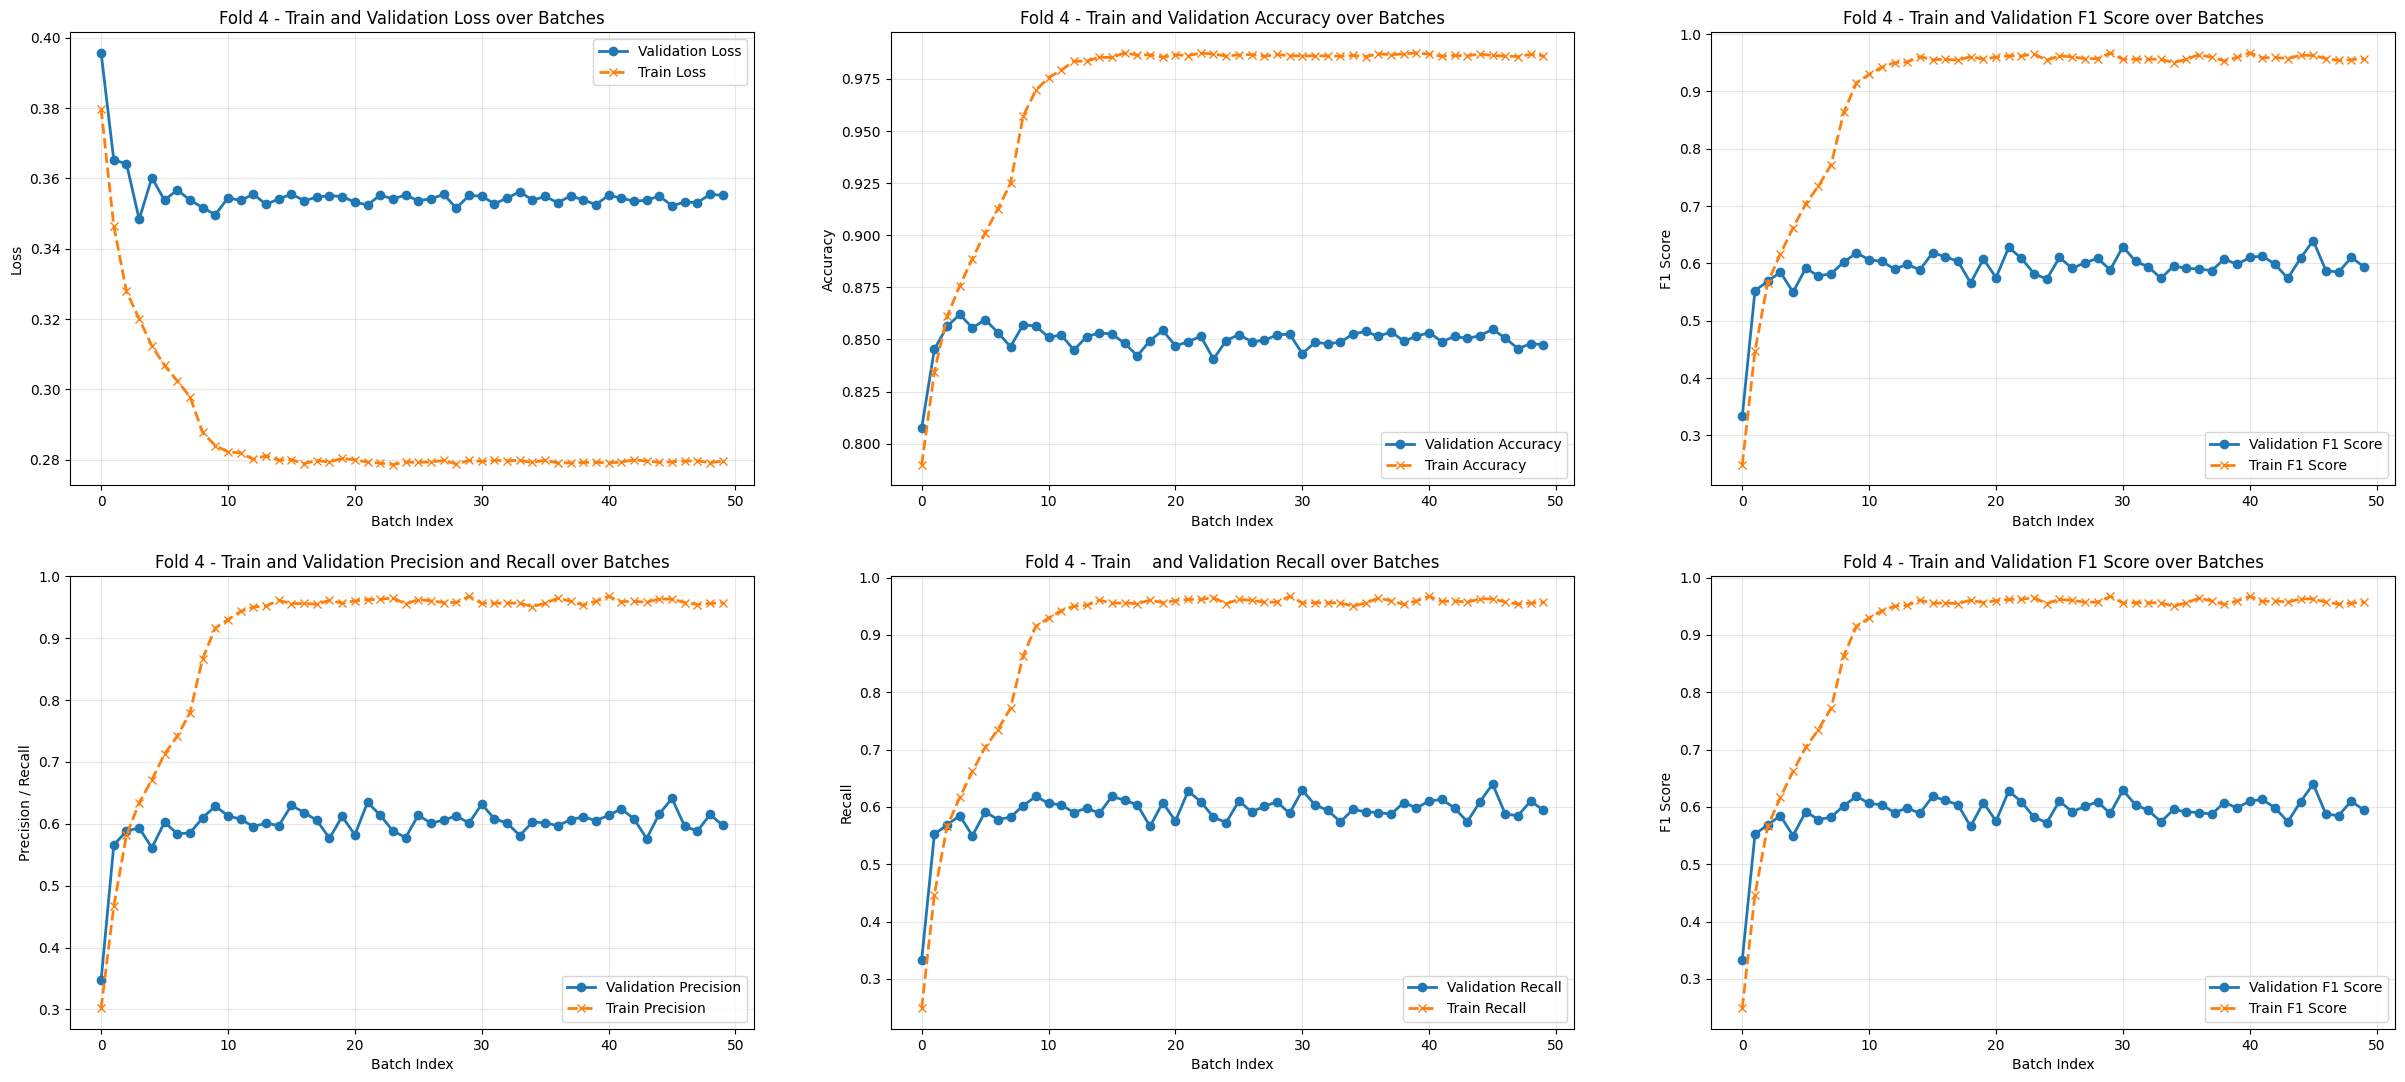

Fold 4 - Mean Validation Loss: 0.355325, Std Validation Loss: 0.006374
Fold 4 - Mean Train Loss: 0.286990, Std Train Loss: 0.019236
Fold 4 - Mean Validation Accuracy: 0.849899, Std Validation Accuracy: 0.007287
Fold 4 - Mean Train Accuracy: 0.966868, Std Train Accuracy: 0.044257
Fold 4 - Mean Validation Precision: 0.597467, Std Validation Precision: 0.039541
Fold 4 - Mean Train Precision: 0.899449, Std Train Precision: 0.140007
Fold 4 - Mean Validation Recall: 0.590215, Std Validation Recall: 0.040889
Fold 4 - Mean Train Recall: 0.896133, Std Train Recall: 0.147772
Fold 4 - Mean Validation F1 Score: 0.590215, Std Validation F1 Score: 0.040889
Fold 4 - Mean Train F1 Score: 0.896133, Std Train F1 Score: 0.147772


In [ ]:
calc_metrics()